# **Skill Gap Model Building**

## **Get data from Kagglehub**

In [ ]:
import pandas as pd

In [239]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saugataroyarghya/resume-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'resume-dataset' dataset.
Path to dataset files: /kaggle/input/resume-dataset


In [240]:
import os

print(os.listdir(path))

['resume_data.csv']


In [241]:
df = pd.read_csv(os.path.join(path, "resume_data.csv"))

print(df.head())

  address                                   career_objective  \
0     NaN  Big data analytics working and database wareho...   
1     NaN  Fresher looking to join as a data analyst and ...   
2     NaN                                                NaN   
3     NaN  To obtain a position in a fast-paced business ...   
4     NaN  Professional accountant with an outstanding wo...   

                                              skills  \
0  ['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...   
1  ['Data Analysis', 'Data Analytics', 'Business ...   
2  ['Software Development', 'Machine Learning', '...   
3  ['accounts payables', 'accounts receivables', ...   
4  ['Analytical reasoning', 'Compliance testing k...   

                        educational_institution_name  \
0  ['The Amity School of Engineering & Technology...   
1  ['Delhi University - Hansraj College', 'Delhi ...   
2    ['Birla Institute of Technology (BIT), Ranchi']   
3  ['Martinez Adult Education, Business Training ...  

## **Analyzing the Data**

In [242]:
df.shape

(9544, 35)

In [243]:
df.columns

Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', '﻿job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')

In [244]:
df.isnull().sum()

,0
address,8760
career_objective,4804
skills,56
educational_institution_name,84
degree_names,84
passing_years,84
educational_results,84
result_types,84
major_field_of_studies,84
professional_company_names,84


In [245]:
df.describe()

,matched_score
count,9544.000000
mean,0.660831
std,0.167040
min,0.000000
25%,0.583333
50%,0.683333
75%,0.793333
max,0.970000


In [246]:
df["matched_score"].dtype

dtype('float64')

In [247]:
df["matched_score"].describe()

,matched_score
count,9544.000000
mean,0.660831
std,0.167040
min,0.000000
25%,0.583333
50%,0.683333
75%,0.793333
max,0.970000


In [248]:
df["matched_score"].nunique()

345

In [249]:
df.duplicated().sum()

np.int64(0)

In [250]:
import seaborn as sns

print(sns.__version__)
print(sns.__file__)

0.13.2
/usr/local/lib/python3.13/dist-packages/seaborn/__init__.py


In [251]:
import seaborn as sns

print(hasattr(sns, "histplot"))

True


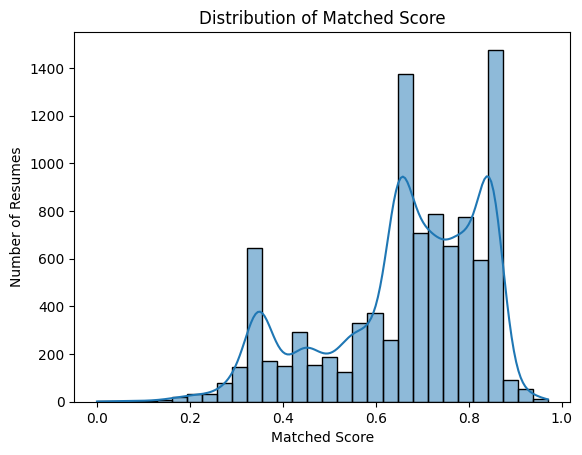

In [252]:
import matplotlib.pyplot as plt

sns.histplot(data=df, x="matched_score", bins=30, kde=True)

plt.xlabel("Matched Score")
plt.ylabel("Number of Resumes")
plt.title("Distribution of Matched Score")
plt.show()

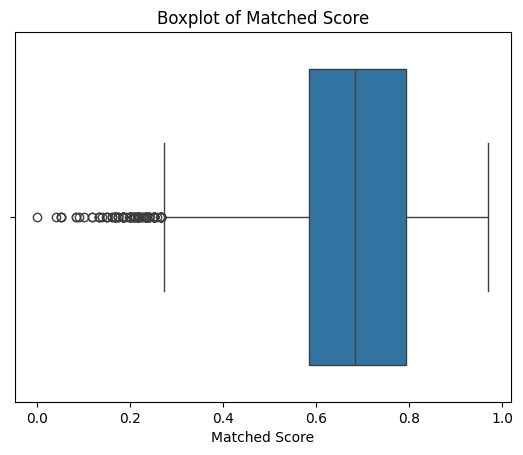

In [253]:
sns.boxplot(x=df["matched_score"])

plt.xlabel("Matched Score")
plt.title("Boxplot of Matched Score")
plt.show()

In [254]:
for col in df.columns:
    print(col)

address
career_objective
skills
educational_institution_name
degree_names
passing_years
educational_results
result_types
major_field_of_studies
professional_company_names
company_urls
start_dates
end_dates
related_skils_in_job
positions
locations
responsibilities
extra_curricular_activity_types
extra_curricular_organization_names
extra_curricular_organization_links
role_positions
languages
proficiency_levels
certification_providers
certification_skills
online_links
issue_dates
expiry_dates
﻿job_position_name
educationaL_requirements
experiencere_requirement
age_requirement
responsibilities.1
skills_required
matched_score


In [255]:
df.columns = df.columns.str.strip()

In [256]:
df.columns = df.columns.str.replace('\ufeff', '', regex=False)



In [257]:
df.columns

Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', 'job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score'],
      dtype='object')

In [258]:
df[[
    "skills",
    "job_position_name",
    "educationaL_requirements",
    "experiencere_requirement",
    "responsibilities.1",
    "skills_required",
    "matched_score"
]].head(5)


,skills,job_position_name,educationaL_requirements,experiencere_requirement,responsibilities.1,skills_required,matched_score
0,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,"['Data Analysis', 'Data Analytics', 'Business ...",Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,"['Software Development', 'Machine Learning', '...","Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,"['accounts payables', 'accounts receivables', ...",Business Development Executive,Bachelor/Honors,1 to 3 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,"['Analytical reasoning', 'Compliance testing k...",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [259]:
df[[
    "skills",
    "job_position_name",
    "educationaL_requirements",
    "experiencere_requirement",
    "responsibilities.1",
    "skills_required",
    "matched_score"
]].dtypes

,0
skills,object
job_position_name,object
educationaL_requirements,object
experiencere_requirement,object
responsibilities.1,object
skills_required,object
matched_score,float64


In [260]:
type(df["skills"].iloc[0])

str

In [261]:
print(df["skills"].iloc[0])

['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure']


## **Converting string into py list**

In [262]:
import ast #use to convert string into python list

In [263]:
skills = ast.literal_eval(df["skills"].iloc[0])

print(skills)
print(type(skills))

['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure']
<class 'list'>


In [264]:
len(skills)


21

In [265]:
print(skills[0])
print(skills[1])
print(skills[-1])

Big Data
Hadoop
Microsoft Azure


In [266]:
df["skills"].isnull().sum()

np.int64(56)

In [267]:
df["skills_list"] = df["skills"].fillna("[]").apply(ast.literal_eval)

In [268]:
df["skills"]

,skills
0,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr..."
1,"['Data Analysis', 'Data Analytics', 'Business ..."
2,"['Software Development', 'Machine Learning', '..."
3,"['accounts payables', 'accounts receivables', ..."
4,"['Analytical reasoning', 'Compliance testing k..."
...,...
9539,"['Mathematical modelling', 'Machine Learning',..."
9540,"['Data Analysis', 'Business Analysis', 'Machin..."
9541,"['Business Analyst', 'Data Analytics', 'Data C..."
9542,"['Machine Learning', 'Natural Language Process..."


In [269]:
df["skills_list"].iloc[0]

['Big Data',
 'Hadoop',
 'Hive',
 'Python',
 'Mapreduce',
 'Spark',
 'Java',
 'Machine Learning',
 'Cloud',
 'Hdfs',
 'YARN',
 'Core Java',
 'Data Science',
 'C++',
 'Data Structures',
 'DBMS',
 'RDBMS',
 'Informatica',
 'Talend',
 'Amazon Redshift',
 'Microsoft Azure']

In [270]:
df["skills_list"]

,skills_list
0,"[Big Data, Hadoop, Hive, Python, Mapreduce, Sp..."
1,"[Data Analysis, Data Analytics, Business Analy..."
2,"[Software Development, Machine Learning, Deep ..."
3,"[accounts payables, accounts receivables, Acco..."
4,"[Analytical reasoning, Compliance testing know..."
...,...
9539,"[Mathematical modelling, Machine Learning, Pre..."
9540,"[Data Analysis, Business Analysis, Machine Lea..."
9541,"[Business Analyst, Data Analytics, Data Cleans..."
9542,"[Machine Learning, Natural Language Processing..."


In [271]:
df["skills"].isnull().sum()

np.int64(56)

In [272]:
df["skills_list"] = df["skills"].fillna("[]").apply(ast.literal_eval)

In [273]:
type(df["skills_list"].iloc[0])

list

In [274]:
df["skill_count"] = df["skills_list"].apply(len)

In [275]:
df[["skills_list", "skill_count"]].head()

,skills_list,skill_count
0,"[Big Data, Hadoop, Hive, Python, Mapreduce, Sp...",21
1,"[Data Analysis, Data Analytics, Business Analy...",10
2,"[Software Development, Machine Learning, Deep ...",14
3,"[accounts payables, accounts receivables, Acco...",36
4,"[Analytical reasoning, Compliance testing know...",32


In [276]:
df["skill_count"].describe()

,skill_count
count,9544.000000
mean,21.638935
std,19.275480
min,0.000000
25%,10.000000
50%,14.000000
75%,29.000000
max,144.000000


In [277]:
df["skill_count"].value_counts().sort_index().head(10)

,count
skill_count,
0,112
3,56
4,152
5,56
6,532
7,392
8,420
9,448
10,766


## **Checking Correltion Between skill_count and matched_score**

In [278]:
df[["skill_count", "matched_score"]].corr()

,skill_count,matched_score
skill_count,1.000000,0.102134
matched_score,0.102134,1.000000


In [279]:
df["skills_required"].head()

,skills_required
0,NaN
1,NaN
2,Brand Promotion\nCampaign Management\nField Su...
3,Fast typing skill\nIELTSInternet browsing & on...
4,iOS\niOS App Developer\niOS Application Develo...


In [280]:
df["skills_required"].head(10)

,skills_required
0,NaN
1,NaN
2,Brand Promotion\nCampaign Management\nField Su...
3,Fast typing skill\nIELTSInternet browsing & on...
4,iOS\niOS App Developer\niOS Application Develo...
5,Python\nR or Java\nTensorFlow\nPyTorch\nScikit...
6,iOS\niOS App Developer\niOS Application Develo...
7,iOS\niOS App Developer\niOS Application Develo...
8,Maintenance and Troubleshooting\nMechanical
9,Fast typing skill\nIELTSInternet browsing & on...


In [281]:
df["skills_required"].isnull().sum()

np.int64(1701)

In [282]:
df["skills_required"].dtype

dtype('O')

In [283]:
df["skills_required"].dropna().iloc[0]

'Brand Promotion\nCampaign Management\nField Supervision\nMerchandising\npromotional activities\nTrade Marketing'

In [284]:
df["skills_required"].notnull().sum()

np.int64(7843)

In [285]:
df["skills_required"].isnull().mean() * 100

np.float64(17.822715842414084)

## **Fill the null value by fillna()**

In [286]:
df["skills_required"] = df["skills_required"].fillna("")

In [287]:
df

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,skills_list,skill_count
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,,0.850000,"[Big Data, Hadoop, Hive, Python, Mapreduce, Sp...",21
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,,0.750000,"[Data Analysis, Data Analytics, Business Analy...",10
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667,"[Software Development, Machine Learning, Deep ...",14
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000,"[accounts payables, accounts receivables, Acco...",36
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000,"[Analytical reasoning, Compliance testing know...",32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9539,NaN,NaN,"['Mathematical modelling', 'Machine Learning',...",['Sanghvi College of Engineering'],['B.Tech'],['2019'],['N/A'],['N/A'],['N/A'],['BPM Foundation'],...,NaN,Data Engineer,Bachelor of Science (BSc),5 to 8 years,NaN,Data Platform Design\nData Pipeline Developmen...,Azure\nBig Data\nData Analytics\nETL Tools\nPo...,0.683333,"[Mathematical modelling, Machine Learning, Pre...",8
9540,NaN,Expertise EDA modeler. I like to learn what my...,"['Data Analysis', 'Business Analysis', 'Machin...","['KVoCT, Pune', 'KVoCT, Pune']","['B.CA', 'M.CA']","['2018', '2020']","[None, None]","[None, None]","[None, None]",['Passionate Solution'],...,NaN,Executive/ Sr. Executive -IT,Bachelor of Science (BSc) in Computer Science ...,3 to 5 years,Age at most 40 years,Hardware & Software Installation\nSystem Monit...,,0.650000,"[Data Analysis, Business Analysis, Machine Lea...",16
9541,NaN,Looking for roles related to application devel...,"['Business Analyst', 'Data Analytics', 'Data C...

In [288]:
df["skills_required"].isnull().sum()

np.int64(0)

In [289]:
df["skills_required"] = df["skills_required"].fillna("")

In [290]:
df["skills_required"].isnull().sum()

np.int64(0)

In [291]:
df["skills_required"].iloc[2]

'Brand Promotion\nCampaign Management\nField Supervision\nMerchandising\npromotional activities\nTrade Marketing'

In [292]:
df["skills_required"].iloc[5]

'Python\nR or Java\nTensorFlow\nPyTorch\nScikit-learn.'

In [293]:
text = "Python\nR or Java\nTensorFlow\nPyTorch\nScikit-learn"

skills = text.split("\n")

print(skills)

['Python', 'R or Java', 'TensorFlow', 'PyTorch', 'Scikit-learn']


In [294]:
df["skills_required_list"] = df["skills_required"].apply(lambda x: x.split("\n") if x else [])

In [295]:
df[["skills_required", "skills_required_list"]].head()

,skills_required,skills_required_list
0,,[]
1,,[]
2,Brand Promotion\nCampaign Management\nField Su...,"[Brand Promotion, Campaign Management, Field S..."
3,Fast typing skill\nIELTSInternet browsing & on...,"[Fast typing skill, IELTSInternet browsing & o..."
4,iOS\niOS App Developer\niOS Application Develo...,"[iOS, iOS App Developer, iOS Application Devel..."


In [296]:
df["skills_required_list"] = df["skills_required_list"].apply(
    lambda skills: [skill.strip() for skill in skills]
)

In [297]:
df["skills_required_list"].head(10)

,skills_required_list
0,[]
1,[]
2,"[Brand Promotion, Campaign Management, Field S..."
3,"[Fast typing skill, IELTSInternet browsing & o..."
4,"[iOS, iOS App Developer, iOS Application Devel..."
5,"[Python, R or Java, TensorFlow, PyTorch, Sciki..."
6,"[iOS, iOS App Developer, iOS Application Devel..."
7,"[iOS, iOS App Developer, iOS Application Devel..."
8,"[Maintenance and Troubleshooting, Mechanical]"
9,"[Fast typing skill, IELTSInternet browsing & o..."


In [298]:
df["skills_required_list"].isnull().sum()

np.int64(0)

In [299]:
resume_skills = df["skills_list"].iloc[0]

print(resume_skills)

['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica', 'Talend', 'Amazon Redshift', 'Microsoft Azure']


In [300]:
job_skills = df["skills_required_list"].iloc[0]

print(job_skills)

[]


In [301]:
common_skills = set(resume_skills) & set(job_skills)

print(common_skills)

set()


In [302]:
matched_skill_count = len(common_skills)

print(matched_skill_count)

0


In [303]:
resume_skills = df["skills_list"].iloc[5]
job_skills = df["skills_required_list"].iloc[5]

print("Resume skills:", resume_skills)
print("Job skills:", job_skills)

Resume skills: ['Microsoft Applications', 'Network Security', 'Networking', 'PC hardware and software installation, configuration, and troubleshooting', 'Remote Desktop and Help Desk Management', 'Verbal Communication', 'Technical Support', 'Team Leadership', 'Programming Languages', 'On-call tech support', 'Windows & Mac OS', 'Wiring/Wire Spicing: Cat3, Cat5, Cat5e, Coaxial', 'Management', 'VoIP, TCP/IP, IPSec, ATM, SS7, IPX, DNS, BIND, DHCP, HSRP and LAN/WAN architecture', 'Application Development', 'Voice Over IP Telephone', 'Inventory Management']
Job skills: ['Python', 'R or Java', 'TensorFlow', 'PyTorch', 'Scikit-learn.']


In [304]:
common_skills = set(resume_skills) & set(job_skills)

print("Common skills:", common_skills)
print("Matched skill count:", len(common_skills))

Common skills: set()
Matched skill count: 0


In [ ]:
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score,skills_list,skill_count,skills_required_list
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,,0.850000,"[Big Data, Hadoop, Hive, Python, Mapreduce, Sp...",21,[]
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,,0.750000,"[Data Analysis, Data Analytics, Business Analy...",10,[]
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667,"[Software Development, Machine Learning, Deep ...",14,"[Brand Promotion, Campaign Management, Field S..."
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000,"[accounts payables, accounts receivables, Acco...",36,"[Fast typing skill, IELTSInternet browsing & o..."
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000,"[Analytical reasoning, Compliance testing know...",32,"[iOS, iOS App Developer, iOS Application Devel..."


## **Data Cleaning**

In [306]:
resume_skills = [skill.strip().lower() for skill in resume_skills]
job_skills = [skill.strip().lower() for skill in job_skills]

print("resume_skills:", resume_skills)
print("job_skills:", job_skills)

resume_skills: ['microsoft applications', 'network security', 'networking', 'pc hardware and software installation, configuration, and troubleshooting', 'remote desktop and help desk management', 'verbal communication', 'technical support', 'team leadership', 'programming languages', 'on-call tech support', 'windows & mac os', 'wiring/wire spicing: cat3, cat5, cat5e, coaxial', 'management', 'voip, tcp/ip, ipsec, atm, ss7, ipx, dns, bind, dhcp, hsrp and lan/wan architecture', 'application development', 'voice over ip telephone', 'inventory management']
job_skills: ['python', 'r or java', 'tensorflow', 'pytorch', 'scikit-learn.']


In [307]:
import re

resume_skills = [re.sub(r"[^\w\s+#.-]", "", skill) for skill in resume_skills]
job_skills = [re.sub(r"[^\w\s+#.-]", "", skill) for skill in job_skills]

print("Resume skills:", resume_skills)
print("Job skills:", job_skills)

Resume skills: ['microsoft applications', 'network security', 'networking', 'pc hardware and software installation configuration and troubleshooting', 'remote desktop and help desk management', 'verbal communication', 'technical support', 'team leadership', 'programming languages', 'on-call tech support', 'windows  mac os', 'wiringwire spicing cat3 cat5 cat5e coaxial', 'management', 'voip tcpip ipsec atm ss7 ipx dns bind dhcp hsrp and lanwan architecture', 'application development', 'voice over ip telephone', 'inventory management']
Job skills: ['python', 'r or java', 'tensorflow', 'pytorch', 'scikit-learn.']


In [308]:
job_skills = [skill.rstrip(".,;:") for skill in job_skills]

print("Job skills:", job_skills)

Job skills: ['python', 'r or java', 'tensorflow', 'pytorch', 'scikit-learn']


In [309]:
resume_skill = "java"
job_skill = "r or java"

print(resume_skill in job_skill)

True


In [310]:
def skill_match(resume_skill, job_skill):
    if resume_skill == job_skill:
        return True

    if job_skill == "r or java" and resume_skill in ["r", "java"]:
        return True

    return False

In [311]:
print(skill_match("java", "r or java"))
print(skill_match("python", "python"))
print(skill_match("java", "python"))

True
True
False


In [312]:
matches = []

for resume_skill in resume_skills:
    for job_skill in job_skills:
        if skill_match(resume_skill, job_skill):
            matches.append(resume_skill)

print("Matched skills:", matches)
print("Number of matched skills:", len(matches))

Matched skills: []
Number of matched skills: 0


In [313]:
test_resume = ["python", "java", "sql"]
test_job = ["python", "r or java", "tensorflow"]

matches = []

for resume_skill in test_resume:
    for job_skill in test_job:
        if skill_match(resume_skill, job_skill):
            matches.append(resume_skill)

print("Matched skills:", matches)
print("Number of matched skills:", len(matches))

Matched skills: ['python', 'java']
Number of matched skills: 2


# **Feature Eng For actual data set**

In [314]:
def count_matched_skills(row):
  count=0
  resume = set(row["skills_list"])
  job = set(row["skills_required_list"])

  for resume_skill in resume:
    for job_skill in job:
      if skill_match(resume_skill,job_skill):
        count+=1
        break

  return count

In [315]:
df["matched_skill_count"] = df.apply(count_matched_skills, axis=1)

In [ ]:
df[["skill_count", "matched_skill_count", "matched_score"]].head(20)

,skill_count,matched_skill_count,matched_score
0,21,0,0.850000
1,10,0,0.750000
2,14,0,0.416667
3,36,0,0.760000
4,32,0,0.650000
5,17,0,0.850000
6,6,0,0.650000
7,52,0,0.650000
8,18,0,0.550000
9,17,0,0.383333


In [317]:
resume_skills = df["skills_list"].iloc[15]
job_skills = df["skills_required_list"].iloc[15]

print("Resume skills:")
print(resume_skills)

print("\nJob skills:")
print(job_skills)

Resume skills:
['Machine Learning', 'Method Development', 'Artificial Intelligence', 'Data Modeling', 'Data Visualization', 'Data Validation', 'Deep Learning', 'MySQL', 'MongoDB', 'Python', 'Plotly', 'Seaborn', 'Matplotlib']

Job skills:
['ASP.NET MVC Strong understanding of database design', 'Database Administrator (DBA)', 'Database management', 'Elasticsearch', 'MongoDB', 'MySQL database', 'NoSQL database', 'REDIS']


In [318]:
matches = []

for resume_skill in resume_skills:
    for job_skill in job_skills:
        if skill_match(resume_skill, job_skill):
            matches.append((resume_skill, job_skill))

print("Matches:", matches)

Matches: [('MongoDB', 'MongoDB')]


In [319]:
def skill_match(resume_skill, job_skill):
    resume_skill = resume_skill.lower().strip()
    job_skill = job_skill.lower().strip()

    return resume_skill in job_skill or job_skill in resume_skill

In [320]:
matches = []

for resume_skill in resume_skills:
    for job_skill in job_skills:
        if skill_match(resume_skill, job_skill):
            matches.append((resume_skill, job_skill))

print("Matches:", matches)

Matches: [('MySQL', 'MySQL database'), ('MongoDB', 'MongoDB')]


In [321]:
def count_matched_skills(row):
    resume = set(row["skills_list"])
    job = row["skills_required_list"]

    count = 0

    for resume_skill in resume:
        for job_skill in job:
            if skill_match(resume_skill, job_skill):
                count += 1
                break

    return count

In [322]:
df["matched_skill_count"] = df.apply(count_matched_skills, axis=1)

In [ ]:
df[[
    "skill_count",
    "matched_skill_count",
    "matched_score"
]].head(20)

,skill_count,matched_skill_count,matched_score
0,21,0,0.850000
1,10,0,0.750000
2,14,1,0.416667
3,36,1,0.760000
4,32,0,0.650000
5,17,0,0.850000
6,6,0,0.650000
7,52,0,0.650000
8,18,0,0.550000
9,17,0,0.383333


In [ ]:
df["matched_skill_count"].describe()

,matched_skill_count
count,9544.000000
mean,0.281643
std,0.643765
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,7.000000


In [ ]:
df[["matched_skill_count", "matched_score"]].corr()

,matched_skill_count,matched_score
matched_skill_count,1.000000,0.089248
matched_score,0.089248,1.000000


In [ ]:
df["matched_skill_count"].value_counts().sort_index()

,count
matched_skill_count,
0,7581
1,1439
2,384
3,97
4,31
5,7
6,4
7,1


In [ ]:
df.groupby("matched_skill_count")["matched_score"].mean()

,matched_score
matched_skill_count,
0,0.655148
1,0.665856
2,0.729718
3,0.739381
4,0.684086
5,0.758571
6,0.746667
7,0.693333


In [328]:
df["job_skill_count"] = df["skills_required_list"].apply(len)

In [ ]:
df[["skill_count", "matched_skill_count", "job_skill_count"]].head(10)

,skill_count,matched_skill_count,job_skill_count
0,21,0,0
1,10,0,0
2,14,1,6
3,36,1,2
4,32,0,8
5,17,0,5
6,6,0,8
7,52,0,8
8,18,0,2
9,17,0,2


In [330]:
df["skill_gap"] = df["job_skill_count"] - df["matched_skill_count"]

In [ ]:
df[["matched_skill_count", "job_skill_count", "skill_gap"]].head(10)

,matched_skill_count,job_skill_count,skill_gap
0,0,0,0
1,0,0,0
2,1,6,5
3,1,2,1
4,0,8,8
5,0,5,5
6,0,8,8
7,0,8,8
8,0,2,2
9,0,2,2


In [332]:
df["match_ratio"] = (
    df["matched_skill_count"] / df["job_skill_count"]
).fillna(0)

In [ ]:
df[[
    "matched_skill_count",
    "job_skill_count",
    "skill_gap",
    "match_ratio"
]].head(10)

,matched_skill_count,job_skill_count,skill_gap,match_ratio
0,0,0,0,0.000000
1,0,0,0,0.000000
2,1,6,5,0.166667
3,1,2,1,0.500000
4,0,8,8,0.000000
5,0,5,5,0.000000
6,0,8,8,0.000000
7,0,8,8,0.000000
8,0,2,2,0.000000
9,0,2,2,0.000000


In [ ]:
df["match_ratio"].describe()

,match_ratio
count,9544.000000
mean,0.071432
std,0.182882
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


In [ ]:
df[df["match_ratio"] > 1][
    ["skills_list", "skills_required_list",
     "matched_skill_count", "job_skill_count", "match_ratio"]
].head(10)

,skills_list,skills_required_list,matched_skill_count,job_skill_count,match_ratio
400,"[MS Office, Minitab, PowerPoint, Excel, Solid ...",[Human Resource Management],2,1,2.0
632,"[Python, C, Java, PostGreSQL, PL/pgSQL, SQLite...",[Human Resource Management],2,1,2.0
729,"[C, R, Catia, AutoCAD, ANSYS, Microsoft office...",[Human Resource Management],2,1,2.0
1002,"[Academic, acrylic, AutoCAD, CAD, concept, Eng...","[AutoCAD, Solidworks]",3,2,1.5
1186,"[C, R, Catia, AutoCAD, ANSYS, Microsoft office...","[AutoCAD, Solidworks]",3,2,1.5
1559,"[Maintenance, Corrective Maintenance, Document...","[Maintenance and Troubleshooting, Mechanical]",4,2,2.0
1624,"[C, SQL, Python, R, Tableau, HP ALM Quality ce...",[Human Resource Management],2,1,2.0
1700,"[MS Office, Minitab, PowerPoint, Excel, Solid ...","[AutoCAD, Solidworks]",3,2,1.5
2027,[Power User of Microsoft Excel Epicor NetSuite...,[Human Resource Management],2,1,2.0
2689,"[Technical Support, Telecom Support, Networkin...","[Cisco, Linux, Operation & Maintenance of Server]",6,3,2.0


In [336]:
def calculate_match(resume_skills, job_skills):
    resume_set = set(resume_skills)
    job_set = set(job_skills)

    matches = resume_set & job_set

    return len(matches)

In [337]:
df["matched_skill_count"] = df.apply(
    lambda row: calculate_match(
        row["skills_list"],
        row["skills_required_list"]
    ),
    axis=1
)

In [338]:
df["job_skill_count"] = df["skills_required_list"].apply(len)

In [339]:
df["skill_gap"] = (
    df["job_skill_count"] - df["matched_skill_count"]
)

In [340]:
df["match_ratio"] = (
    df["matched_skill_count"] / df["job_skill_count"]
).fillna(0)

In [ ]:
df["match_ratio"].describe()

,match_ratio
count,9544.000000
mean,0.009847
std,0.051199
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
df[df["match_ratio"] > 1]

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,responsibilities.1,skills_required,matched_score,skills_list,skill_count,skills_required_list,matched_skill_count,job_skill_count,skill_gap,match_ratio


In [ ]:
df["match_ratio"].value_counts().sort_index()

,count
match_ratio,
0.000000,9125
0.111111,4
0.125000,50
0.166667,122
0.200000,119
0.250000,49
0.333333,40
0.400000,11
0.500000,21


In [ ]:
df[df["matched_skill_count"] > 0][
    ["skills_list",
     "skills_required_list",
     "matched_skill_count",
     "job_skill_count",
     "match_ratio"]
].head(20)

,skills_list,skills_required_list,matched_skill_count,job_skill_count,match_ratio
15,"[Machine Learning, Method Development, Artific...",[ASP.NET MVC Strong understanding of database ...,1,8,0.125000
29,"[Machine Learning, Method Development, Artific...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",1,5,0.200000
81,"[Python, Java, HTML 5, SQL, C Programming, Exc...","[Business Analysis, Effective communication sk...",1,6,0.166667
83,"[Requirement Analysis, Machine Learning, Predi...","[Azure, Big Data, Data Analytics, ETL Tools, P...",1,6,0.166667
91,"[Business Analysis, Machine Learning, Requirem...","[Business Analysis, Effective communication sk...",1,6,0.166667
92,"[Machine Learning, Natural Language Processing...","[Azure, Big Data, Data Analytics, ETL Tools, P...",1,6,0.166667
145,"[Data Analyst, Database Management, Data Integ...","[Azure, Big Data, Data Analytics, ETL Tools, P...",2,6,0.333333
212,"[Data Science, Data Analytics, Database Manage...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",1,5,0.200000
248,"[Software Development, Client Management, Tech...","[Business Analysis, Effective communication sk...",1,6,0.166667
257,"[PLC, IEC 61131 (Ladder Logic, Functional Bloc...","[AutoCAD, ETABS, Microsoft Office Suite, MS Pr...",1,4,0.250000


In [345]:
def calculate_matches(resume_skills, job_skills):
    resume_set = set(resume_skills)
    job_set = set(job_skills)

    matches = resume_set & job_set

    return matches


print(calculate_matches(
    df["skills_list"].iloc[344],
    df["skills_required_list"].iloc[344]
))

{'TensorFlow', 'Python'}


In [346]:
def normalize_skill(skill):
    skill = skill.lower()
    skill = skill.replace(".", "")
    skill = skill.replace("-", " ")
    skill = skill.strip()
    return skill

In [347]:
print(normalize_skill("JAVA"))
print(normalize_skill("Java"))
print(normalize_skill("Scikit-Learn"))
print(normalize_skill("Scikit-learn."))

java
java
scikit learn
scikit learn


In [348]:
def calculate_matches(resume_skills, job_skills):
  resume_set = {normalize_skill(skill) for skill in resume_skills}
  job_set = {normalize_skill(skill) for skill in job_skills}

  matches = resume_set & job_set

  return matches

In [349]:
matches = calculate_matches(
    df["skills_list"].iloc[344],
    df["skills_required_list"].iloc[344]
)

print(matches)
print("Number of matches:", len(matches))

{'tensorflow', 'scikit learn', 'python'}
Number of matches: 3


In [350]:
def calculate_matches(resume_skills, job_skills):
    matches = []

    for resume_skill in resume_skills:
        for job_skill in job_skills:
            if skill_match(
                normalize_skill(resume_skill),
                normalize_skill(job_skill)
            ):
                matches.append(resume_skill)
                break

    return matches

In [351]:
print(calculate_matches(
    df["skills_list"].iloc[344],
    df["skills_required_list"].iloc[344]
))

['C', 'Python', 'JAVA', 'Scikit-Learn', 'TensorFlow']


In [ ]:
df[["skills_list","skills_required_list"]].iloc[344]

,344
skills_list,"[C, C++, Python, JAVA, HTML, CSS, JavaScript, ..."
skills_required_list,"[Python, R or Java, TensorFlow, PyTorch, Sciki..."


## **Recaluculate all acc. to new skill match method:**

In [353]:
def skill_match(resume_skill, job_skill):
    resume_skill = normalize_skill(resume_skill)
    job_skill = normalize_skill(job_skill)

    # Exact match
    if resume_skill == job_skill:
        return True

    # Special case: R or Java
    if job_skill == "r or java" and resume_skill in ["r", "java"]:
        return True

    # Special case: database wording
    if job_skill == "mysql database" and resume_skill == "mysql":
        return True

    return False

In [354]:
matches = calculate_matches(
    df["skills_list"].iloc[344],
    df["skills_required_list"].iloc[344]
)

print(matches)
print("Number of matches:", len(matches))

['Python', 'JAVA', 'Scikit-Learn', 'TensorFlow']
Number of matches: 4


In [355]:
df["matched_skill_count"] = df.apply(
    lambda row: len(calculate_matches(
        row["skills_list"],
        row["skills_required_list"]
    )),
    axis=1
)

In [356]:
df["skill_gap"] = (
    df["job_skill_count"] - df["matched_skill_count"]
)

In [357]:
df["match_ratio"] = (
    df["matched_skill_count"] / df["job_skill_count"]
).fillna(0)

In [ ]:
df[[
    "skill_count",
    "job_skill_count",
    "matched_skill_count",
    "skill_gap",
    "match_ratio",
    "matched_score"
]].head(20)

,skill_count,job_skill_count,matched_skill_count,skill_gap,match_ratio,matched_score
0,21,0,0,0,0.00,0.850000
1,10,0,0,0,0.00,0.750000
2,14,6,0,6,0.00,0.416667
3,36,2,0,2,0.00,0.760000
4,32,8,0,8,0.00,0.650000
5,17,5,0,5,0.00,0.850000
6,6,8,0,8,0.00,0.650000
7,52,8,0,8,0.00,0.650000
8,18,2,0,2,0.00,0.550000
9,17,2,0,2,0.00,0.383333


In [ ]:
df[df["matched_skill_count"] > 0][
    ["skills_list",
     "skills_required_list",
     "matched_skill_count",
     "job_skill_count",
     "match_ratio"]
].head(20)

,skills_list,skills_required_list,matched_skill_count,job_skill_count,match_ratio
15,"[Machine Learning, Method Development, Artific...",[ASP.NET MVC Strong understanding of database ...,2,8,0.250000
29,"[Machine Learning, Method Development, Artific...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",1,5,0.200000
77,"[Net, photo, agile, analyst, Apple, automation...","[Business Analysis, Effective communication sk...",1,6,0.166667
81,"[Python, Java, HTML 5, SQL, C Programming, Exc...","[Business Analysis, Effective communication sk...",1,6,0.166667
83,"[Requirement Analysis, Machine Learning, Predi...","[Azure, Big Data, Data Analytics, ETL Tools, P...",1,6,0.166667
91,"[Business Analysis, Machine Learning, Requirem...","[Business Analysis, Effective communication sk...",1,6,0.166667
92,"[Machine Learning, Natural Language Processing...","[Azure, Big Data, Data Analytics, ETL Tools, P...",1,6,0.166667
145,"[Data Analyst, Database Management, Data Integ...","[Azure, Big Data, Data Analytics, ETL Tools, P...",2,6,0.333333
153,"[Machine Learning, Artificial Intelligence, Py...","[Azure, Big Data, Data Analytics, ETL Tools, P...",1,6,0.166667
212,"[Data Science, Data Analytics, Database Manage...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",1,5,0.200000


In [ ]:
df[df["match_ratio"] > 1]

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,responsibilities.1,skills_required,matched_score,skills_list,skill_count,skills_required_list,matched_skill_count,job_skill_count,skill_gap,match_ratio


In [ ]:
df["match_ratio"].describe()

,match_ratio
count,9544.000000
mean,0.014249
std,0.069913
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
df["matched_skill_count"].value_counts().sort_index()

,count
matched_skill_count,
0,9028
1,401
2,94
3,16
4,4
5,1


In [ ]:
df["job_skill_count"].value_counts().sort_index()

,count
job_skill_count,
0,1701
1,683
2,1364
3,1364
4,1367
5,341
6,1021
7,341
8,1021


In [364]:
df = df[df["job_skill_count"] > 0].copy()

In [365]:
df.shape

(7843, 42)

In [ ]:
df["job_skill_count"].value_counts().sort_index()

,count
job_skill_count,
1,683
2,1364
3,1364
4,1367
5,341
6,1021
7,341
8,1021
9,341


In [ ]:
df["matched_skill_count"].value_counts().sort_index()

,count
matched_skill_count,
0,7327
1,401
2,94
3,16
4,4
5,1


In [ ]:
df["match_ratio"].describe()

,match_ratio
count,7843.000000
mean,0.017339
std,0.076775
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
df[df["match_ratio"] > 0]["match_ratio"].value_counts().sort_index()

,count
match_ratio,
0.111111,17
0.125000,67
0.166667,125
0.200000,85
0.250000,61
0.333333,55
0.375000,1
0.400000,48
0.500000,30


In [ ]:
df['match_ratio'].describe()

,match_ratio
count,7843.000000
mean,0.017339
std,0.076775
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
df.columns.tolist()

['address',
 'career_objective',
 'skills',
 'educational_institution_name',
 'degree_names',
 'passing_years',
 'educational_results',
 'result_types',
 'major_field_of_studies',
 'professional_company_names',
 'company_urls',
 'start_dates',
 'end_dates',
 'related_skils_in_job',
 'positions',
 'locations',
 'responsibilities',
 'extra_curricular_activity_types',
 'extra_curricular_organization_names',
 'extra_curricular_organization_links',
 'role_positions',
 'languages',
 'proficiency_levels',
 'certification_providers',
 'certification_skills',
 'online_links',
 'issue_dates',
 'expiry_dates',
 'job_position_name',
 'educationaL_requirements',
 'experiencere_requirement',
 'age_requirement',
 'responsibilities.1',
 'skills_required',
 'matched_score',
 'skills_list',
 'skill_count',
 'skills_required_list',
 'matched_skill_count',
 'job_skill_count',
 'skill_gap',
 'match_ratio']

In [ ]:
df[[
    "skill_count",
    "job_skill_count",
    "matched_skill_count",
    "skill_gap",
    "match_ratio"
]].corr()

,skill_count,job_skill_count,matched_skill_count,skill_gap,match_ratio
skill_count,1.000000,0.000418,0.026309,-0.003467,0.052974
job_skill_count,0.000418,1.000000,0.104104,0.989144,0.042773
matched_skill_count,0.026309,0.104104,1.000000,-0.043177,0.929697
skill_gap,-0.003467,0.989144,-0.043177,1.000000,-0.094399
match_ratio,0.052974,0.042773,0.929697,-0.094399,1.000000


In [373]:
y = df["match_ratio"]

In [374]:
X = df[["skill_count", "job_skill_count"]]

In [ ]:
df[[
    "skills",
    "skills_required",
    "matched_skill_count",
    "match_ratio"
]].head(10)

,skills,skills_required,matched_skill_count,match_ratio
2,"['Software Development', 'Machine Learning', '...",Brand Promotion\nCampaign Management\nField Su...,0,0.0
3,"['accounts payables', 'accounts receivables', ...",Fast typing skill\nIELTSInternet browsing & on...,0,0.0
4,"['Analytical reasoning', 'Compliance testing k...",iOS\niOS App Developer\niOS Application Develo...,0,0.0
5,"['Microsoft Applications', 'Network Security',...",Python\nR or Java\nTensorFlow\nPyTorch\nScikit...,0,0.0
6,"['Machine Learning', 'Linear Regression', 'Rid...",iOS\niOS App Developer\niOS Application Develo...,0,0.0
7,"['Maintenance', 'Corrective Maintenance', 'Doc...",iOS\niOS App Developer\niOS Application Develo...,0,0.0
8,"['Python', 'Machine Learning', 'MySQL', 'Data ...",Maintenance and Troubleshooting\nMechanical,0,0.0
9,"['Django', 'Python', 'Relational databases', '...",Fast typing skill\nIELTSInternet browsing & on...,0,0.0
10,"['Microsoft Office Suite', 'VideoScribe Softwa...",AutoCAD\nSolidworks,0,0.0
11,"['R', 'Python', 'Tableau', 'Power BI', 'SQL', ...",•Administration\n•Health Safety and Environmen...,0,0.0


In [ ]:
print("Resume skills:")
print(df.loc[5, "skills"])

print("\nJob skills:")
print(df.loc[5, "skills_required"])

print("\nTypes:")
print(type(df.loc[5, "skills"]))
print(type(df.loc[5, "skills_required"]))



Resume skills:
['Microsoft Applications', 'Network Security', 'Networking', 'PC hardware and software installation, configuration, and troubleshooting', 'Remote Desktop and Help Desk Management', 'Verbal Communication', 'Technical Support', 'Team Leadership', 'Programming Languages', 'On-call tech support', 'Windows & Mac OS', 'Wiring/Wire Spicing: Cat3, Cat5, Cat5e, Coaxial', 'Management', 'VoIP, TCP/IP, IPSec, ATM, SS7, IPX, DNS, BIND, DHCP, HSRP and LAN/WAN architecture', 'Application Development', 'Voice Over IP Telephone', 'Inventory Management']

Job skills:
Python
R or Java
TensorFlow
PyTorch
Scikit-learn.

Types:
<class 'str'>
<class 'str'>


In [ ]:
print("Normalized resume:")
print([normalize_skill(x) for x in df.loc[5, "skills"]])

print("\nNormalized job:")
print([normalize_skill(x) for x in df.loc[5, "skills_required_list"]])


Normalized resume:
['[', "'", 'm', 'i', 'c', 'r', 'o', 's', 'o', 'f', 't', '', 'a', 'p', 'p', 'l', 'i', 'c', 'a', 't', 'i', 'o', 'n', 's', "'", ',', '', "'", 'n', 'e', 't', 'w', 'o', 'r', 'k', '', 's', 'e', 'c', 'u', 'r', 'i', 't', 'y', "'", ',', '', "'", 'n', 'e', 't', 'w', 'o', 'r', 'k', 'i', 'n', 'g', "'", ',', '', "'", 'p', 'c', '', 'h', 'a', 'r', 'd', 'w', 'a', 'r', 'e', '', 'a', 'n', 'd', '', 's', 'o', 'f', 't', 'w', 'a', 'r', 'e', '', 'i', 'n', 's', 't', 'a', 'l', 'l', 'a', 't', 'i', 'o', 'n', ',', '', 'c', 'o', 'n', 'f', 'i', 'g', 'u', 'r', 'a', 't', 'i', 'o', 'n', ',', '', 'a', 'n', 'd', '', 't', 'r', 'o', 'u', 'b', 'l', 'e', 's', 'h', 'o', 'o', 't', 'i', 'n', 'g', "'", ',', '', "'", 'r', 'e', 'm', 'o', 't', 'e', '', 'd', 'e', 's', 'k', 't', 'o', 'p', '', 'a', 'n', 'd', '', 'h', 'e', 'l', 'p', '', 'd', 'e', 's', 'k', '', 'm', 'a', 'n', 'a', 'g', 'e', 'm', 'e', 'n', 't', "'", ',', '', "'", 'v', 'e', 'r', 'b', 'a', 'l', '', 'c', 'o', 'm', 'm', 'u', 'n', 'i', 'c', 'a', 't', 'i', 

In [ ]:
print(df.loc[5, "skills_list"])
print()
print(df.loc[5, "skills_required_list"])

['Microsoft Applications', 'Network Security', 'Networking', 'PC hardware and software installation, configuration, and troubleshooting', 'Remote Desktop and Help Desk Management', 'Verbal Communication', 'Technical Support', 'Team Leadership', 'Programming Languages', 'On-call tech support', 'Windows & Mac OS', 'Wiring/Wire Spicing: Cat3, Cat5, Cat5e, Coaxial', 'Management', 'VoIP, TCP/IP, IPSec, ATM, SS7, IPX, DNS, BIND, DHCP, HSRP and LAN/WAN architecture', 'Application Development', 'Voice Over IP Telephone', 'Inventory Management']

['Python', 'R or Java', 'TensorFlow', 'PyTorch', 'Scikit-learn.']


In [ ]:
print(df.loc[5, "skills_list"])
print()
print(df.loc[5, "skills_required_list"])

['Microsoft Applications', 'Network Security', 'Networking', 'PC hardware and software installation, configuration, and troubleshooting', 'Remote Desktop and Help Desk Management', 'Verbal Communication', 'Technical Support', 'Team Leadership', 'Programming Languages', 'On-call tech support', 'Windows & Mac OS', 'Wiring/Wire Spicing: Cat3, Cat5, Cat5e, Coaxial', 'Management', 'VoIP, TCP/IP, IPSec, ATM, SS7, IPX, DNS, BIND, DHCP, HSRP and LAN/WAN architecture', 'Application Development', 'Voice Over IP Telephone', 'Inventory Management']

['Python', 'R or Java', 'TensorFlow', 'PyTorch', 'Scikit-learn.']


In [ ]:
print("Normalized resume:")
print([normalize_skill(x) for x in df.loc[5, "skills_list"]])

print("\nNormalized job:")
print([normalize_skill(x) for x in df.loc[5, "skills_required_list"]])

Normalized resume:
['microsoft applications', 'network security', 'networking', 'pc hardware and software installation, configuration, and troubleshooting', 'remote desktop and help desk management', 'verbal communication', 'technical support', 'team leadership', 'programming languages', 'on call tech support', 'windows & mac os', 'wiring/wire spicing: cat3, cat5, cat5e, coaxial', 'management', 'voip, tcp/ip, ipsec, atm, ss7, ipx, dns, bind, dhcp, hsrp and lan/wan architecture', 'application development', 'voice over ip telephone', 'inventory management']

Normalized job:
['python', 'r or java', 'tensorflow', 'pytorch', 'scikit learn']


In [ ]:
df["matched_skills"] = df.apply(
    lambda row: calculate_matches(
        row["skills_list"],
        row["skills_required_list"]
    ),
    axis=1
)

df["matched_skill_count"] = df["matched_skills"].apply(len)

df["job_skill_count"] = df["skills_required_list"].apply(len)

df["match_ratio"] = (
    df["matched_skill_count"] / df["job_skill_count"]
).fillna(0)

In [ ]:
df["matched_skill_count"].value_counts().sort_index()

,count
matched_skill_count,
0,7327
1,401
2,94
3,16
4,4
5,1


In [ ]:
df["match_ratio"].describe()



,match_ratio
count,7843.000000
mean,0.017339
std,0.076775
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
# Recalculate matching using the LIST columns

df["matched_skills"] = df.apply(
    lambda row: calculate_matches(
        row["skills_list"],
        row["skills_required_list"]
    ),
    axis=1
)

df["matched_skill_count"] = df["matched_skills"].apply(len)

df["job_skill_count"] = df["skills_required_list"].apply(len)

df["match_ratio"] = (
    df["matched_skill_count"] / df["job_skill_count"]
).fillna(0)

In [ ]:
df[[
    "skills_list",
    "skills_required_list",
    "matched_skills",
    "matched_skill_count",
    "job_skill_count",
    "match_ratio"
]].head(10)

,skills_list,skills_required_list,matched_skills,matched_skill_count,job_skill_count,match_ratio
2,"[Software Development, Machine Learning, Deep ...","[Brand Promotion, Campaign Management, Field S...",[],0,6,0.0
3,"[accounts payables, accounts receivables, Acco...","[Fast typing skill, IELTSInternet browsing & o...",[],0,2,0.0
4,"[Analytical reasoning, Compliance testing know...","[iOS, iOS App Developer, iOS Application Devel...",[],0,8,0.0
5,"[Microsoft Applications, Network Security, Net...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",[],0,5,0.0
6,"[Machine Learning, Linear Regression, Ridge Re...","[iOS, iOS App Developer, iOS Application Devel...",[],0,8,0.0
7,"[Maintenance, Corrective Maintenance, Document...","[iOS, iOS App Developer, iOS Application Devel...",[],0,8,0.0
8,"[Python, Machine Learning, MySQL, Data Mining,...","[Maintenance and Troubleshooting, Mechanical]",[],0,2,0.0
9,"[Django, Python, Relational databases, RestAPI...","[Fast typing skill, IELTSInternet browsing & o...",[],0,2,0.0
10,"[Microsoft Office Suite, VideoScribe Software,...","[AutoCAD, Solidworks]",[],0,2,0.0
11,"[R, Python, Tableau, Power BI, SQL, SAS, Deep ...","[•Administration, •Health Safety and Environme...",[],0,3,0.0


In [ ]:
df.loc[344, [
    "skills_list",
    "skills_required_list",
    "matched_skills",
    "matched_skill_count",
    "match_ratio"
]]

,344
skills_list,"[C, C++, Python, JAVA, HTML, CSS, JavaScript, ..."
skills_required_list,"[Python, R or Java, TensorFlow, PyTorch, Sciki..."
matched_skills,"[Python, JAVA, Scikit-Learn, TensorFlow]"
matched_skill_count,4
match_ratio,0.8


In [ ]:
def calculate_skill_gap(resume_skills, job_skills):
    gap = []

    for job_skill in job_skills:
        found = False

        for resume_skill in resume_skills:
            if skill_match(
                normalize_skill(resume_skill),
                normalize_skill(job_skill)
            ):
                found = True
                break

        if not found:
            gap.append(job_skill)

    return gap


df["skill_gap_list"] = df.apply(
    lambda row: calculate_skill_gap(
        row["skills_list"],
        row["skills_required_list"]
    ),
    axis=1
)

In [ ]:
df.loc[344, [
    "skills_list",
    "skills_required_list",
    "matched_skills",
    "skill_gap_list",
    "match_ratio"
]]

,344
skills_list,"[C, C++, Python, JAVA, HTML, CSS, JavaScript, ..."
skills_required_list,"[Python, R or Java, TensorFlow, PyTorch, Sciki..."
matched_skills,"[Python, JAVA, Scikit-Learn, TensorFlow]"
skill_gap_list,[PyTorch]
match_ratio,0.8


In [ ]:
df[[
    "skills_list",
    "skills_required_list",
    "matched_skills",
    "skill_gap_list",
    "matched_skill_count",
    "job_skill_count",
    "match_ratio"
]].head(10)

,skills_list,skills_required_list,matched_skills,skill_gap_list,matched_skill_count,job_skill_count,match_ratio
2,"[Software Development, Machine Learning, Deep ...","[Brand Promotion, Campaign Management, Field S...",[],"[Brand Promotion, Campaign Management, Field S...",0,6,0.0
3,"[accounts payables, accounts receivables, Acco...","[Fast typing skill, IELTSInternet browsing & o...",[],"[Fast typing skill, IELTSInternet browsing & o...",0,2,0.0
4,"[Analytical reasoning, Compliance testing know...","[iOS, iOS App Developer, iOS Application Devel...",[],"[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0
5,"[Microsoft Applications, Network Security, Net...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",[],"[Python, R or Java, TensorFlow, PyTorch, Sciki...",0,5,0.0
6,"[Machine Learning, Linear Regression, Ridge Re...","[iOS, iOS App Developer, iOS Application Devel...",[],"[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0
7,"[Maintenance, Corrective Maintenance, Document...","[iOS, iOS App Developer, iOS Application Devel...",[],"[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0
8,"[Python, Machine Learning, MySQL, Data Mining,...","[Maintenance and Troubleshooting, Mechanical]",[],"[Maintenance and Troubleshooting, Mechanical]",0,2,0.0
9,"[Django, Python, Relational databases, RestAPI...","[Fast typing skill, IELTSInternet browsing & o...",[],"[Fast typing skill, IELTSInternet browsing & o...",0,2,0.0
10,"[Microsoft Office Suite, VideoScribe Software,...","[AutoCAD, Solidworks]",[],"[AutoCAD, Solidworks]",0,2,0.0
11,"[R, Python, Tableau, Power BI, SQL, SAS, Deep ...","[•Administration, •Health Safety and Environme...",[],"[•Administration, •Health Safety and Environme...",0,3,0.0


In [ ]:
df["matched_skill_count"].value_counts().sort_index()

,count
matched_skill_count,
0,7327
1,401
2,94
3,16
4,4
5,1


In [ ]:
df["match_ratio"].describe()

,match_ratio
count,7843.000000
mean,0.017339
std,0.076775
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
for i in range(20):
    print("\nROW:", i)
    print("Resume:", df.iloc[i]["skills_list"])
    print("Job:", df.iloc[i]["skills_required_list"])
    print("Matched:", df.iloc[i]["matched_skills"])
    print("Gap:", df.iloc[i]["skill_gap_list"])
    print("Ratio:", df.iloc[i]["match_ratio"])


ROW: 0
Resume: ['Software Development', 'Machine Learning', 'Deep Learning', 'Risk Assessment', 'Requirement Gathering', 'Application Support', 'JavaScript', 'Python', 'Docker', 'HTML', 'Hive', 'CSS', 'C', 'C++']
Job: ['Brand Promotion', 'Campaign Management', 'Field Supervision', 'Merchandising', 'promotional activities', 'Trade Marketing']
Matched: []
Gap: ['Brand Promotion', 'Campaign Management', 'Field Supervision', 'Merchandising', 'promotional activities', 'Trade Marketing']
Ratio: 0.0

ROW: 1
Resume: ['accounts payables', 'accounts receivables', 'Accounts Payable', 'Accounts Receivable', 'administrative functions', 'trial balance', 'banking', 'budget', 'bi', 'closing', 'Computer Applications', 'Credit', 'clients', 'Customer Service', 'data entry', 'delivery', 'driving', 'email', 'insurance', 'inventory', 'ledger', 'Access', 'Excel', 'Outlook', 'PowerPoint', 'Word', 'mortgage loan', 'Enterprise', 'policies', 'QuickBooks', 'Sales', 'sales reports', 'telecommunications', 'phone',

In [ ]:
import inspect

print(inspect.getsource(normalize_skill))
print()
print(inspect.getsource(skill_match))

def normalize_skill(skill):
    skill = skill.lower()
    skill = skill.replace(".", "")
    skill = skill.replace("-", " ")
    skill = skill.strip()
    return skill


def skill_match(resume_skill, job_skill):
    resume_skill = normalize_skill(resume_skill)
    job_skill = normalize_skill(job_skill)

    # Exact match
    if resume_skill == job_skill:
        return True

    # Special case: R or Java
    if job_skill == "r or java" and resume_skill in ["r", "java"]:
        return True

    # Special case: database wording
    if job_skill == "mysql database" and resume_skill == "mysql":
        return True

    return False



In [ ]:
def normalize_skill(skill):
    skill = skill.lower().strip()
    skill = skill.replace(".", "")
    skill = skill.replace("-", " ")

    # Remove extra spaces
    skill = " ".join(skill.split())

    # Skill aliases
    aliases = {
        "java": "java",
        "javascript": "javascript",
        "scikit learn": "scikit learn",
        "scikit-learn": "scikit learn",
        "auto cad": "autocad",
        "autocad": "autocad",
        "tensorflow keras": "tensorflow",
        "mysql database": "mysql",
    }

    return aliases.get(skill, skill)

In [ ]:
def skill_match(resume_skill, job_skill):

    resume_skill = normalize_skill(resume_skill)
    job_skill = normalize_skill(job_skill)

    # Exact match
    if resume_skill == job_skill:
        return True

    # R or Java
    if job_skill == "r or java" and resume_skill in ["r", "java"]:
        return True

    return False

In [ ]:
df["matched_skills"] = df.apply(
    lambda row: calculate_matches(
        row["skills_list"],
        row["skills_required_list"]
    ),
    axis=1
)

df["matched_skill_count"] = df["matched_skills"].apply(len)

df["skill_gap_list"] = df.apply(
    lambda row: calculate_skill_gap(
        row["skills_list"],
        row["skills_required_list"]
    ),
    axis=1
)

df["job_skill_count"] = df["skills_required_list"].apply(len)

df["match_ratio"] = (
    df["matched_skill_count"] / df["job_skill_count"]
).fillna(0)

In [ ]:
df.loc[344, [
    "skills_list",
    "skills_required_list",
    "matched_skills",
    "skill_gap_list",
    "matched_skill_count",
    "match_ratio"
]]

,344
skills_list,"[C, C++, Python, JAVA, HTML, CSS, JavaScript, ..."
skills_required_list,"[Python, R or Java, TensorFlow, PyTorch, Sciki..."
matched_skills,"[Python, JAVA, Scikit-Learn, TensorFlow]"
skill_gap_list,[PyTorch]
matched_skill_count,4
match_ratio,0.8


In [ ]:
model_df = df[[
    "skills_list",
    "skills_required_list",
    "matched_skill_count",
    "job_skill_count",
    "match_ratio"
]].copy()

model_df.head()

,skills_list,skills_required_list,matched_skill_count,job_skill_count,match_ratio
2,"[Software Development, Machine Learning, Deep ...","[Brand Promotion, Campaign Management, Field S...",0,6,0.0
3,"[accounts payables, accounts receivables, Acco...","[Fast typing skill, IELTSInternet browsing & o...",0,2,0.0
4,"[Analytical reasoning, Compliance testing know...","[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0
5,"[Microsoft Applications, Network Security, Net...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",0,5,0.0
6,"[Machine Learning, Linear Regression, Ridge Re...","[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0


In [ ]:
model_df.shape

(7843, 5)

In [ ]:
df[[
    "skills_list",
    "skills_required_list",
    "matched_skills",
    "skill_gap_list",
    "matched_skill_count",
    "job_skill_count",
    "match_ratio"
]].head(100)

,skills_list,skills_required_list,matched_skills,skill_gap_list,matched_skill_count,job_skill_count,match_ratio
2,"[Software Development, Machine Learning, Deep ...","[Brand Promotion, Campaign Management, Field S...",[],"[Brand Promotion, Campaign Management, Field S...",0,6,0.0
3,"[accounts payables, accounts receivables, Acco...","[Fast typing skill, IELTSInternet browsing & o...",[],"[Fast typing skill, IELTSInternet browsing & o...",0,2,0.0
4,"[Analytical reasoning, Compliance testing know...","[iOS, iOS App Developer, iOS Application Devel...",[],"[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0
5,"[Microsoft Applications, Network Security, Net...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",[],"[Python, R or Java, TensorFlow, PyTorch, Sciki...",0,5,0.0
6,"[Machine Learning, Linear Regression, Ridge Re...","[iOS, iOS App Developer, iOS Application Devel...",[],"[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0
...,...,...,...,...,...,...,...
119,"[Game Theory, Bounded Rationality, Cryptograph...","[Auto CAD 2D 3D, Civil 3D, Civil Construction,...",[],"[Auto CAD 2D 3D, Civil 3D, Civil Construction,...",0,4,0.0
121,"[Microsoft Office, Account Reconciliation Proc...",[ASP.NET MVC Strong understanding of database ...,[],[ASP.NET MVC Strong understanding of database ...,0,8,0.0
122,"[Proactive, self-motivated, team player, AP, A...","[iOS, iOS App Developer, iOS Application Devel...",[],"[iOS, iOS App Developer, iOS Application Devel...",0,8,0.0
123,"[Python, Webscrapping, PowerBI, Data Cleaning,...","[Cisco, Linux, Operation & Maintenance of Server]",[],"[Cisco, Linux, Operation & Maintenance of Server]",0,3,0.0


In [ ]:
df[df["matched_skill_count"] > 0][["skills_list", "skills_required_list", "matched_skills", "skill_gap_list", "job_skill_count", "match_ratio"]].head(100)


,skills_list,skills_required_list,matched_skills,skill_gap_list,job_skill_count,match_ratio
15,"[Machine Learning, Method Development, Artific...",[ASP.NET MVC Strong understanding of database ...,"[MySQL, MongoDB]",[ASP.NET MVC Strong understanding of database ...,8,0.250000
29,"[Machine Learning, Method Development, Artific...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",[Python],"[R or Java, TensorFlow, PyTorch, Scikit-learn.]",5,0.200000
77,"[Net, photo, agile, analyst, Apple, automation...","[Business Analysis, Effective communication sk...",[software development],"[Business Analysis, Effective communication sk...",6,0.166667
81,"[Python, Java, HTML 5, SQL, C Programming, Exc...","[Business Analysis, Effective communication sk...",[Java],"[Business Analysis, Effective communication sk...",6,0.166667
83,"[Requirement Analysis, Machine Learning, Predi...","[Azure, Big Data, Data Analytics, ETL Tools, P...",[SQL],"[Azure, Big Data, Data Analytics, ETL Tools, P...",6,0.166667
...,...,...,...,...,...,...
1779,"[Machine Learning, Artificial Intelligence, Py...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",[Python],"[R or Java, TensorFlow, PyTorch, Scikit-learn.]",5,0.200000
1781,"[ArcView, AutoCad, Drafting, GPS, graphic, Ins...","[AutoCAD, Solidworks]",[AutoCad],[Solidworks],2,0.500000
1796,"[Statistical Modeling, Natural Language Proces...","[Python, R or Java, TensorFlow, PyTorch, Sciki...",[Python],"[R or Java, TensorFlow, PyTorch, Scikit-learn.]",5,0.200000
1827,"[Data Analysis, Data Visualization, Data Struc...","[Python, R or Java, TensorFlow, PyTorch, Sciki...","[Python, Java]","[TensorFlow, PyTorch, Scikit-learn.]",5,0.400000


In [ ]:
df[["skills", "skills_list"]].head(10)

,skills,skills_list
2,"['Software Development', 'Machine Learning', '...","[Software Development, Machine Learning, Deep ..."
3,"['accounts payables', 'accounts receivables', ...","[accounts payables, accounts receivables, Acco..."
4,"['Analytical reasoning', 'Compliance testing k...","[Analytical reasoning, Compliance testing know..."
5,"['Microsoft Applications', 'Network Security',...","[Microsoft Applications, Network Security, Net..."
6,"['Machine Learning', 'Linear Regression', 'Rid...","[Machine Learning, Linear Regression, Ridge Re..."
7,"['Maintenance', 'Corrective Maintenance', 'Doc...","[Maintenance, Corrective Maintenance, Document..."
8,"['Python', 'Machine Learning', 'MySQL', 'Data ...","[Python, Machine Learning, MySQL, Data Mining,..."
9,"['Django', 'Python', 'Relational databases', '...","[Django, Python, Relational databases, RestAPI..."
10,"['Microsoft Office Suite', 'VideoScribe Softwa...","[Microsoft Office Suite, VideoScribe Software,..."
11,"['R', 'Python', 'Tableau', 'Power BI', 'SQL', ...","[R, Python, Tableau, Power BI, SQL, SAS, Deep ..."


In [ ]:
df["skills_list"].head(10).tolist()

[['Software Development',
  'Machine Learning',
  'Deep Learning',
  'Risk Assessment',
  'Requirement Gathering',
  'Application Support',
  'JavaScript',
  'Python',
  'Docker',
  'HTML',
  'Hive',
  'CSS',
  'C',
  'C++'],
 ['accounts payables',
  'accounts receivables',
  'Accounts Payable',
  'Accounts Receivable',
  'administrative functions',
  'trial balance',
  'banking',
  'budget',
  'bi',
  'closing',
  'Computer Applications',
  'Credit',
  'clients',
  'Customer Service',
  'data entry',
  'delivery',
  'driving',
  'email',
  'insurance',
  'inventory',
  'ledger',
  'Access',
  'Excel',
  'Outlook',
  'PowerPoint',
  'Word',
  'mortgage loan',
  'Enterprise',
  'policies',
  'QuickBooks',
  'Sales',
  'sales reports',
  'telecommunications',
  'phone',
  'workflow',
  'written'],
 ['Analytical reasoning',
  'Compliance testing knowledge',
  'Effective time management',
  'Public and private accounting',
  'accounting',
  'accounting systems',
  'accounts payable',
  'ac

In [ ]:
df["skills_list"].apply(len).value_counts().sort_index()

,count
skills_list,
0,92
3,46
4,127
5,46
6,437
...,...
90,23
91,23
106,23


In [ ]:
type(df["skills_list"].iloc[0])

list

In [ ]:
for i in range(5):
    print(df["skills_list"].iloc[i])

['Software Development', 'Machine Learning', 'Deep Learning', 'Risk Assessment', 'Requirement Gathering', 'Application Support', 'JavaScript', 'Python', 'Docker', 'HTML', 'Hive', 'CSS', 'C', 'C++']
['accounts payables', 'accounts receivables', 'Accounts Payable', 'Accounts Receivable', 'administrative functions', 'trial balance', 'banking', 'budget', 'bi', 'closing', 'Computer Applications', 'Credit', 'clients', 'Customer Service', 'data entry', 'delivery', 'driving', 'email', 'insurance', 'inventory', 'ledger', 'Access', 'Excel', 'Outlook', 'PowerPoint', 'Word', 'mortgage loan', 'Enterprise', 'policies', 'QuickBooks', 'Sales', 'sales reports', 'telecommunications', 'phone', 'workflow', 'written']
['Analytical reasoning', 'Compliance testing knowledge', 'Effective time management', 'Public and private accounting', 'accounting', 'accounting systems', 'accounts payable', 'accounts receivable', 'administrative', 'AR', 'billing', 'closing', 'client', 'clients', 'documentation', 'financial'

In [ ]:
df[["skills_list", "skills_required_list"]].head()

,skills_list,skills_required_list
2,"[Software Development, Machine Learning, Deep ...","[Brand Promotion, Campaign Management, Field S..."
3,"[accounts payables, accounts receivables, Acco...","[Fast typing skill, IELTSInternet browsing & o..."
4,"[Analytical reasoning, Compliance testing know...","[iOS, iOS App Developer, iOS Application Devel..."
5,"[Microsoft Applications, Network Security, Net...","[Python, R or Java, TensorFlow, PyTorch, Sciki..."
6,"[Machine Learning, Linear Regression, Ridge Re...","[iOS, iOS App Developer, iOS Application Devel..."


In [ ]:
df

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,matched_score,skills_list,skill_count,skills_required_list,matched_skill_count,job_skill_count,skill_gap,match_ratio,matched_skills,skill_gap_list
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,0.416667,"[Software Development, Machine Learning, Deep ...",14,"[Brand Promotion, Campaign Management, Field S...",0,6,6,0.0,[],"[Brand Promotion, Campaign Management, Field S..."
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,0.760000,"[accounts payables, accounts receivables, Acco...",36,"[Fast typing skill, IELTSInternet browsing & o...",0,2,2,0.0,[],"[Fast typing skill, IELTSInternet browsing & o..."
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,0.650000,"[Analytical reasoning, Compliance testing know...",32,"[iOS, iOS App Developer, iOS Application Devel...",0,8,8,0.0,[],"[iOS, iOS App Developer, iOS Application Devel..."
5,NaN,"To secure an IT specialist, desktop support, n...","['Microsoft Applications', 'Network Security',...","['Glen Oaks High School', 'Glen Oaks High Scho...","['Bachelor Degree', 'Associate Degree']","[None, None]","[None, None]","[None, None]",['Electronics and Communications Engineering T...,"['N/A', 'Company Name', 'Company Name']",...,0.850000,"[Microsoft Applications, Network Security, Net...",17,"[Python, R or Java, TensorFlow, PyTorch, Sciki...",0,5,5,0.0,[],"[Python, R or Java, TensorFlow, PyTorch, Sciki..."
6,NaN,NaN,"['Machine Learning', 'Linear Regression', 'Rid...",['DJR College and University'],['B.Tech'],['2020'],['N/A'],['N/A'],['IT'],['Remiro Amio'],...,0.650000,"[Machine Learning, Linear Regression, Ridge Re...",6,"[iOS, iOS App Developer, iOS Application Devel...",0,8,8,0.0,[],"[iOS, iOS App Developer, iOS Application Devel..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9538,NaN,To advance in professional and personal experi...,"['Microsoft applications', 'Excellent writing ...","['Kings College', 'South Carolina State Univer...","['Diploma', 'Bachelor of Science']","['2004', '1995']","[None, None]","[None, None]","['Accounting', 'Computer Science']","['Company Name', 'Company Name', 'Company Name...",...,0.770000,"[Microsoft applications, Excellent writing ski...",63,"[Python, R or Java, TensorFlow, PyTorch, Sciki...",0,5,5,0.0,[],"[Python, R or Java, TensorFlow, PyTorch, Sciki..."
9539,NaN,NaN,"['Mathematical modelling', 'Machine Learning',...",['Sanghvi College of Engineering'],['B.Tech'],['2019'],['N/A'],['N/A'],['N/A'],['BPM Foundation'],...,0.683333,"[Mathematical modelling, Machine Learning, Pre...",8,"[Azure, Big Data, Data Analytics, ETL Tools, P...",0,6,6,0.0,[],"[Azure, Big Data, Data Analytics, ETL Tools, P..."
9541,NaN,Looking for roles related to application devel...,"['Business Analyst', 'Data Analytics', 'Data C...",['PGG College Mysore'],['B.BA'],['2019'],['N/A'],['N/A'],['N/A'],['ZigSAW'],...,0.650000,"[Business Analyst, Data Analytics, Data Cleans...",10,[VAT and Tax],0,1,1,0.0,[],[VAT and Tax]
9542,NaN,NaN,"['Machine Learning', 'Natural Language Process...","['Rajiv Gandhi Memorial University, Delhi']",['B.TECH'],['2020'],['N/A'],['N/A'],['Electrical'],['Zynta Labs'],...,0.650000,"[Machine Learning, Natural Language 

In [ ]:
df["resume_skill_text"] = df["skills_list"].apply(
      lambda x: " ".join(x)
)

df["job_skill_text"] = df["skills_required_list"].apply(
          lambda x: " ".join(x)
)

In [ ]:
df[["resume_skill_text", "job_skill_text"]].head()

,resume_skill_text,job_skill_text
2,Software Development Machine Learning Deep Lea...,Brand Promotion Campaign Management Field Supe...
3,accounts payables accounts receivables Account...,Fast typing skill IELTSInternet browsing & onl...
4,Analytical reasoning Compliance testing knowle...,iOS iOS App Developer iOS Application Developm...
5,Microsoft Applications Network Security Networ...,Python R or Java TensorFlow PyTorch Scikit-learn.
6,Machine Learning Linear Regression Ridge Regre...,iOS iOS App Developer iOS Application Developm...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

resume_tfidf = vectorizer.fit_transform(df["resume_skill_text"])
job_tfidf = vectorizer.transform(df["job_skill_text"])

print("Resume TF-IDF shape:", resume_tfidf.shape)
print("Job TF-IDF shape:", job_tfidf.shape)

Resume TF-IDF shape: (7843, 2471)
Job TF-IDF shape: (7843, 2471)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_scores = []

for i in range(len(df)):
    score = cosine_similarity(
            resume_tfidf[i],
            job_tfidf[i]
    )[0][0]
    cosine_scores.append(score)

df["cosine_similarity"] = cosine_scores

In [ ]:
df[[
    "resume_skill_text",
    "job_skill_text",
    "cosine_similarity"
]].head()

,resume_skill_text,job_skill_text,cosine_similarity
2,Software Development Machine Learning Deep Lea...,Brand Promotion Campaign Management Field Supe...,0.0
3,accounts payables accounts receivables Account...,Fast typing skill IELTSInternet browsing & onl...,0.0
4,Analytical reasoning Compliance testing knowle...,iOS iOS App Developer iOS Application Developm...,0.0
5,Microsoft Applications Network Security Networ...,Python R or Java TensorFlow PyTorch Scikit-learn.,0.0
6,Machine Learning Linear Regression Ridge Regre...,iOS iOS App Developer iOS Application Developm...,0.0


In [ ]:
(df["cosine_similarity"] > 0).sum()

np.int64(2665)

In [ ]:
df["cosine_similarity"].describe()

,cosine_similarity
count,7843.000000
mean,0.019953
std,0.043255
min,0.000000
25%,0.000000
50%,0.000000
75%,0.021432
max,0.554151


In [ ]:
df[[
    "resume_skill_text",
    "job_skill_text",
    "cosine_similarity"
]].sort_values(
   by="cosine_similarity",
   ascending=False
).head(10)

,resume_skill_text,job_skill_text,cosine_similarity
660,Skill 1 Skill 3 Skill 5 Skill 2 Skill 4 Skill 6,Fast typing skill IELTSInternet browsing & onl...,0.554151
3955,Bluebeam Mathcad Microsoft Word Excel Project ...,Auto CAD 2D 3D Civil 3D Civil Construction Civ...,0.501890
7082,Skill 1 Skill 3 Skill 5 Skill 2 Skill 4 Skill 6,Computer skill Good communication skills Mecha...,0.433677
153,Machine Learning Artificial Intelligence Pytho...,Azure Big Data Data Analytics ETL Tools Power ...,0.364263
5695,Machine Learning Natural Language Processing D...,Python R or Java TensorFlow PyTorch Scikit-learn.,0.345987
871,Python Scikit Learn Keras Tensorflow Object Or...,Python R or Java TensorFlow PyTorch Scikit-learn.,0.343793
8110,Software Development Data Science Data Analysi...,Ansible AWS Cloud Cloud Platform DevOps Docker...,0.340664
8897,Python Machine Learning Deep Learning Data Ana...,Python R or Java TensorFlow PyTorch Scikit-learn.,0.338211
5059,Python Machine Learning Natural Language Proce...,Azure Big Data Data Analytics ETL Tools Power ...,0.338008
2635,Data Analytics Business Analysis Business Inte...,Azure Big Data Data Analytics ETL Tools Power ...,0.336625


In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
resume_embeddings = model.encode(
    df["resume_skill_text"].tolist(),
    show_progress_bar=True
)

job_embeddings = model.encode(
    df["job_skill_text"].tolist(),
    show_progress_bar=True
)


Batches:   0%|          | 0/246 [00:00<?, ?it/s]

Batches:   0%|          | 0/246 [00:00<?, ?it/s]

# Model Evaluation: Rule-Based vs TF-IDF vs Semantic Similarity

In [ ]:
# Recreate semantic similarity if it is missing from df
from sklearn.metrics.pairwise import cosine_similarity

if "semantic_similarity" not in df.columns:
    semantic_scores = []

    for i in range(len(df)):
        score = cosine_similarity(
            resume_embeddings[i].reshape(1, -1),
            job_embeddings[i].reshape(1, -1)
        )[0][0]

        semantic_scores.append(score)

    df["semantic_similarity"] = semantic_scores

print("semantic_similarity available:", "semantic_similarity" in df.columns)


semantic_similarity available: True


In [ ]:
# Create a reproducible 20-row evaluation sample

evaluation_df = df[[
    "resume_skill_text",
    "job_skill_text",
    "match_ratio",
    "cosine_similarity",
    "semantic_similarity"
]].sample(20, random_state=42).copy()

# Initial human relevance labels:
# 0 = Not relevant
# 1 = Relevant
labels = [
    0, 0, 1, 0, 0,
    1, 0, 1, 0, 0,
    1, 1, 0, 1, 1,
    1, 1, 1, 0, 0
]

evaluation_df["relevance_label"] = labels

evaluation_df[[
    "match_ratio",
    "cosine_similarity",
    "semantic_similarity",
    "relevance_label"
]]


,match_ratio,cosine_similarity,semantic_similarity,relevance_label
9303,0.000,0.000000,0.314403,0
2630,0.000,0.000000,0.062277,0
4167,0.000,0.027588,0.277319,1
2305,0.000,0.000000,0.091830,0
1756,0.000,0.036560,0.067817,0
4028,0.000,0.074523,0.174040,1
5924,0.000,0.073630,0.304872,0
2990,0.125,0.033412,0.109089,1
9383,0.000,0.117428,0.107117,0
7630,0.000,0.000000,-0.013623,0


## Exploratory prediction thresholds

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rule_pred = (evaluation_df["match_ratio"] > 0).astype(int)
tfidf_pred = (evaluation_df["cosine_similarity"] > 0).astype(int)
semantic_pred = (evaluation_df["semantic_similarity"] > 0.20).astype(int)

y_true = evaluation_df["relevance_label"]

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0)
    }

results = {
    "Rule-Based": evaluate_model(y_true, rule_pred),
    "TF-IDF": evaluate_model(y_true, tfidf_pred),
    "Semantic": evaluate_model(y_true, semantic_pred)
}

results_df = pd.DataFrame(results).T
results_df


,Accuracy,Precision,Recall,F1 Score
Rule-Based,0.65,1.000000,0.3,0.461538
TF-IDF,0.60,0.583333,0.7,0.636364
Semantic,0.55,0.555556,0.5,0.526316


## Observed exploratory results
### Interpretation

# Current Project Status
### Completed
### Next Development Phase

# Skill Prioritization

In [ ]:
# Build a global demand-frequency table from job-required skills

from collections import Counter

job_skill_counter = Counter()

for skill_list in df["skills_required_list"]:
    for skill in skill_list:
        normalized = normalize_skill(skill)
        if normalized:
            job_skill_counter[normalized] += 1

skill_demand_df = pd.DataFrame(
    job_skill_counter.items(),
    columns=["normalized_skill", "job_demand_count"]
).sort_values(
    "job_demand_count",
    ascending=False
).reset_index(drop=True)

skill_demand_df.head(20)


,normalized_skill,job_demand_count
0,autocad,1025
1,human resource management,683
2,java,680
3,etabs,342
4,ms project,342
5,communication and negotiation skills,342
6,internet,342
7,civil construction,342
8,civil engineering,342
9,civil 3d,342


In [ ]:
# Create a demand score between 0 and 1

max_demand = skill_demand_df["job_demand_count"].max()

skill_demand_df["demand_score"] = (
    skill_demand_df["job_demand_count"] / max_demand
)

skill_demand_df.head(20)


,normalized_skill,job_demand_count,demand_score
0,autocad,1025,1.000000
1,human resource management,683,0.666341
2,java,680,0.663415
3,etabs,342,0.333659
4,ms project,342,0.333659
5,communication and negotiation skills,342,0.333659
6,internet,342,0.333659
7,civil construction,342,0.333659
8,civil engineering,342,0.333659
9,civil 3d,342,0.333659


## Prioritize missing skills for each resume-job pair

In [ ]:
def get_skill_priority(missing_skills):
    prioritized = []

    for skill in missing_skills:
        normalized = normalize_skill(skill)
        demand_count = job_skill_counter.get(normalized, 0)
        demand_score = demand_count / max_demand if max_demand else 0

        if demand_score >= 0.50:
            priority = "High"
        elif demand_score >= 0.20:
            priority = "Medium"
        else:
            priority = "Low"

        prioritized.append({
            "skill": skill,
            "normalized_skill": normalized,
            "job_demand_count": demand_count,
            "demand_score": round(demand_score, 4),
            "priority": priority
        })

    return sorted(
        prioritized,
        key=lambda x: x["demand_score"],
        reverse=True
    )


df["prioritized_skill_gap"] = df["skill_gap_list"].apply(
    get_skill_priority
)

df[[
    "skill_gap_list",
    "prioritized_skill_gap"
]].head(10)


,skill_gap_list,prioritized_skill_gap
2,"[Brand Promotion, Campaign Management, Field S...","[{'skill': 'Brand Promotion', 'normalized_skil..."
3,"[Fast typing skill, IELTSInternet browsing & o...","[{'skill': 'Fast typing skill', 'normalized_sk..."
4,"[iOS, iOS App Developer, iOS Application Devel...","[{'skill': 'iOS', 'normalized_skill': 'ios', '..."
5,"[Python, R or Java, TensorFlow, PyTorch, Sciki...","[{'skill': 'Python', 'normalized_skill': 'pyth..."
6,"[iOS, iOS App Developer, iOS Application Devel...","[{'skill': 'iOS', 'normalized_skill': 'ios', '..."
7,"[iOS, iOS App Developer, iOS Application Devel...","[{'skill': 'iOS', 'normalized_skill': 'ios', '..."
8,"[Maintenance and Troubleshooting, Mechanical]","[{'skill': 'Maintenance and Troubleshooting',..."
9,"[Fast typing skill, IELTSInternet browsing & o...","[{'skill': 'Fast typing skill', 'normalized_sk..."
10,"[AutoCAD, Solidworks]","[{'skill': 'AutoCAD', 'normalized_skill': 'aut..."
11,"[•Administration, •Health Safety and Environme...","[{'skill': '•Administration', 'normalized_skil..."


In [ ]:
# Example: inspect a single resume-job pair

example_index = df.index[0]

print("Resume skills:")
print(df.loc[example_index, "skills_list"])

print("\nRequired job skills:")
print(df.loc[example_index, "skills_required_list"])

print("\nMatched skills:")
print(df.loc[example_index, "matched_skills"])

print("\nPrioritized skill gap:")
for item in df.loc[example_index, "prioritized_skill_gap"]:
    print(item)


Resume skills:
['Software Development', 'Machine Learning', 'Deep Learning', 'Risk Assessment', 'Requirement Gathering', 'Application Support', 'JavaScript', 'Python', 'Docker', 'HTML', 'Hive', 'CSS', 'C', 'C++']

Required job skills:
['Brand Promotion', 'Campaign Management', 'Field Supervision', 'Merchandising', 'promotional activities', 'Trade Marketing']

Matched skills:
[]

Prioritized skill gap:
{'skill': 'Brand Promotion', 'normalized_skill': 'brand promotion', 'job_demand_count': 341, 'demand_score': 0.3327, 'priority': 'Medium'}
{'skill': 'Campaign Management', 'normalized_skill': 'campaign management', 'job_demand_count': 341, 'demand_score': 0.3327, 'priority': 'Medium'}
{'skill': 'Field Supervision', 'normalized_skill': 'field supervision', 'job_demand_count': 341, 'demand_score': 0.3327, 'priority': 'Medium'}
{'skill': 'Merchandising', 'normalized_skill': 'merchandising', 'job_demand_count': 341, 'demand_score': 0.3327, 'priority': 'Medium'}
{'skill': 'promotional activiti

# Next Module: Personalized Learning Roadmap

# Personalized Learning Roadmap Engine

In [ ]:
# Curated prerequisite relationships for common technical skills

skill_dependencies = {
    "numpy": ["python"],
    "pandas": ["python", "numpy"],
    "matplotlib": ["python"],
    "seaborn": ["python", "pandas", "matplotlib"],
    "statistics": ["python"],
    "machine learning": ["python", "numpy", "pandas", "statistics"],
    "scikit learn": ["python", "numpy", "pandas", "machine learning"],
    "deep learning": ["python", "numpy", "machine learning"],
    "tensorflow": ["python", "numpy", "deep learning"],
    "pytorch": ["python", "numpy", "deep learning"],
    "keras": ["python", "deep learning", "tensorflow"],
    "natural language processing": ["python", "machine learning"],
    "computer vision": ["python", "numpy", "deep learning"],
    "sql": ["database"],
    "mysql": ["sql", "database"],
    "mongodb": ["database"],
    "data analysis": ["python", "pandas", "statistics"],
    "data science": ["python", "statistics", "data analysis", "machine learning"],
    "power bi": ["data analysis"],
    "tableau": ["data analysis"],
    "docker": ["linux", "software development"],
    "aws": ["cloud computing"],
    "git": ["software development"],
    "github": ["git"],
    "rest apis": ["python", "software development"],
    "flask": ["python", "rest apis"],
    "django": ["python", "software development"],
    "java": ["programming"],
    "c++": ["programming"],
    "javascript": ["programming"],
    "html": ["web development"],
    "css": ["html", "web development"],
    "react": ["javascript", "html", "css"],
    "spring": ["java", "software development"]
}

print("Number of dependency rules:", len(skill_dependencies))


Number of dependency rules: 34


In [ ]:
# Normalize the dependency graph keys and values

skill_dependencies = {
    normalize_skill(skill): [normalize_skill(dep) for dep in dependencies]
    for skill, dependencies in skill_dependencies.items()
}

print("Example dependency:")
print("scikit learn ->", skill_dependencies["scikit learn"])


Example dependency:
scikit learn -> ['python', 'numpy', 'pandas', 'machine learning']


## Build a learning roadmap

In [ ]:
def build_learning_roadmap(resume_skills, prioritized_gap):
    resume_normalized = {
        normalize_skill(skill)
        for skill in resume_skills
    }

    roadmap = []
    visited = set()

    def add_skill(skill, priority="Prerequisite"):
        skill = normalize_skill(skill)

        if not skill or skill in resume_normalized or skill in visited:
            return

        # Add prerequisites first
        for prerequisite in skill_dependencies.get(skill, []):
            if prerequisite not in resume_normalized:
                add_skill(prerequisite, "Prerequisite")

        visited.add(skill)
        roadmap.append({
            "skill": skill,
            "priority": priority
        })

    # Start from highest-demand missing skills
    for item in prioritized_gap:
        add_skill(item["skill"], item["priority"])

    return roadmap


df["learning_roadmap"] = df.apply(
    lambda row: build_learning_roadmap(
        row["skills_list"],
        row["prioritized_skill_gap"]
    ),
    axis=1
)

df[[
    "prioritized_skill_gap",
    "learning_roadmap"
]].head(10)


,prioritized_skill_gap,learning_roadmap
2,"[{'skill': 'Brand Promotion', 'normalized_skil...","[{'skill': 'brand promotion', 'priority': 'Med..."
3,"[{'skill': 'Fast typing skill', 'normalized_sk...","[{'skill': 'fast typing skill', 'priority': 'M..."
4,"[{'skill': 'iOS', 'normalized_skill': 'ios', '...","[{'skill': 'ios', 'priority': 'Medium'}, {'ski..."
5,"[{'skill': 'Python', 'normalized_skill': 'pyth...","[{'skill': 'python', 'priority': 'Medium'}, {'..."
6,"[{'skill': 'iOS', 'normalized_skill': 'ios', '...","[{'skill': 'ios', 'priority': 'Medium'}, {'ski..."
7,"[{'skill': 'iOS', 'normalized_skill': 'ios', '...","[{'skill': 'ios', 'priority': 'Medium'}, {'ski..."
8,"[{'skill': 'Maintenance and Troubleshooting',...","[{'skill': 'maintenance and troubleshooting', ..."
9,"[{'skill': 'Fast typing skill', 'normalized_sk...","[{'skill': 'fast typing skill', 'priority': 'M..."
10,"[{'skill': 'AutoCAD', 'normalized_skill': 'aut...","[{'skill': 'autocad', 'priority': 'High'}, {'s..."
11,"[{'skill': '•Administration', 'normalized_skil...","[{'skill': '•administration', 'priority': 'Med..."


# Learning Resource Recommendation

In [ ]:
resource_map = {
    "python": ["Python fundamentals", "Hands-on coding exercises"],
    "numpy": ["NumPy tutorials", "Numerical computing exercises"],
    "pandas": ["Pandas tutorials", "Data manipulation exercises"],
    "statistics": ["Statistics and probability", "Statistical practice problems"],
    "machine learning": ["ML fundamentals", "Scikit-learn projects"],
    "scikit learn": ["Scikit-learn documentation", "ML practice projects"],
    "deep learning": ["Deep learning fundamentals", "Neural-network projects"],
    "tensorflow": ["TensorFlow tutorials", "Deep learning projects"],
    "pytorch": ["PyTorch tutorials", "Deep learning projects"],
    "natural language processing": ["NLP fundamentals", "NLP projects"],
    "computer vision": ["Computer vision fundamentals", "Computer vision projects"],
    "sql": ["SQL fundamentals", "SQL query practice"],
    "mysql": ["MySQL tutorials", "Database practice"],
    "mongodb": ["MongoDB tutorials", "NoSQL projects"],
    "data analysis": ["Data analysis tutorials", "Data analysis projects"],
    "data science": ["Data science workflow", "End-to-end projects"],
    "power bi": ["Power BI tutorials", "Dashboard projects"],
    "tableau": ["Tableau tutorials", "Visualization projects"],
    "docker": ["Docker fundamentals", "Containerization projects"],
    "aws": ["AWS fundamentals", "Cloud deployment projects"],
    "git": ["Git fundamentals", "Version-control practice"],
    "github": ["GitHub workflow", "Portfolio projects"],
    "rest apis": ["REST API fundamentals", "API development project"],
    "flask": ["Flask tutorials", "API project"],
    "django": ["Django tutorials", "Web application project"],
    "java": ["Java fundamentals", "Java projects"],
    "javascript": ["JavaScript fundamentals", "Web projects"],
    "html": ["HTML fundamentals", "Web development practice"],
    "css": ["CSS fundamentals", "Frontend projects"],
    "react": ["React fundamentals", "Frontend projects"]
}

def recommend_resources(roadmap):
    recommendations = []

    for item in roadmap:
        skill = normalize_skill(item["skill"])

        recommendations.append({
            "skill": item["skill"],
            "priority": item["priority"],
            "resources": resource_map.get(
                skill,
                ["Concept tutorial", "Hands-on practice project"]
            )
        })

    return recommendations


df["learning_resources"] = df["learning_roadmap"].apply(
    recommend_resources
)

df[[
    "learning_roadmap",
    "learning_resources"
]].head(5)


,learning_roadmap,learning_resources
2,"[{'skill': 'brand promotion', 'priority': 'Med...","[{'skill': 'brand promotion', 'priority': 'Med..."
3,"[{'skill': 'fast typing skill', 'priority': 'M...","[{'skill': 'fast typing skill', 'priority': 'M..."
4,"[{'skill': 'ios', 'priority': 'Medium'}, {'ski...","[{'skill': 'ios', 'priority': 'Medium', 'resou..."
5,"[{'skill': 'python', 'priority': 'Medium'}, {'...","[{'skill': 'python', 'priority': 'Medium', 're..."
6,"[{'skill': 'ios', 'priority': 'Medium'}, {'ski...","[{'skill': 'ios', 'priority': 'Medium', 'resou..."


# End-to-End Personalized Learning Pipeline
### Important limitation

In [ ]:
# Display a clean example of the complete recommendation output

def display_recommendation(index):
    row = df.loc[index]

    print("=== PERSONALIZED SKILL GAP REPORT ===")
    print("\nMatched Skills:")
    print(row["matched_skills"])

    print("\nMissing Skills:")
    print(row["skill_gap_list"])

    print("\nPrioritized Gap:")
    for item in row["prioritized_skill_gap"]:
        print(
            f"- {item['skill']} | "
            f"Priority: {item['priority']} | "
            f"Demand: {item['job_demand_count']}"
        )

    print("\nLearning Roadmap:")
    for step, item in enumerate(row["learning_roadmap"], 1):
        print(f"{step}. {item['skill']} ({item['priority']})")

    print("\nLearning Resources:")
    for item in row["learning_resources"]:
        print(f"- {item['skill']}: {', '.join(item['resources'])}")


display_recommendation(df.index[0])


=== PERSONALIZED SKILL GAP REPORT ===

Matched Skills:
[]

Missing Skills:
['Brand Promotion', 'Campaign Management', 'Field Supervision', 'Merchandising', 'promotional activities', 'Trade Marketing']

Prioritized Gap:
- Brand Promotion | Priority: Medium | Demand: 341
- Campaign Management | Priority: Medium | Demand: 341
- Field Supervision | Priority: Medium | Demand: 341
- Merchandising | Priority: Medium | Demand: 341
- promotional activities | Priority: Medium | Demand: 341
- Trade Marketing | Priority: Medium | Demand: 341

Learning Roadmap:
1. brand promotion (Medium)
2. campaign management (Medium)
3. field supervision (Medium)
4. merchandising (Medium)
5. promotional activities (Medium)
6. trade marketing (Medium)

Learning Resources:
- brand promotion: Concept tutorial, Hands-on practice project
- campaign management: Concept tutorial, Hands-on practice project
- field supervision: Concept tutorial, Hands-on practice project
- merchandising: Concept tutorial, Hands-on practi

# Next Development Phase

# Final Recommendation Score

In [ ]:
# Combine semantic similarity, TF-IDF similarity, skill match, and skill demand

import numpy as np

# Normalize the rule-based match ratio
match_component = df["match_ratio"].clip(0, 1)

# Normalize semantic similarity using min-max scaling
sem_min = df["semantic_similarity"].min()
sem_max = df["semantic_similarity"].max()
semantic_component = (df["semantic_similarity"] - sem_min) / (sem_max - sem_min) if sem_max > sem_min else 0

# Normalize TF-IDF similarity using min-max scaling
tfidf_min = df["cosine_similarity"].min()
tfidf_max = df["cosine_similarity"].max()
tfidf_component = (df["cosine_similarity"] - tfidf_min) / (tfidf_max - tfidf_min) if tfidf_max > tfidf_min else 0

# Skill-demand component for the missing skills
def calculate_demand_component(prioritized_gap):
    if not prioritized_gap:
        return 1.0
    scores = [item["demand_score"] for item in prioritized_gap]
    return float(np.mean(scores)) if scores else 0.0

df["skill_demand_component"] = df["prioritized_skill_gap"].apply(calculate_demand_component)

# Final recommendation score
df["recommendation_score"] = (
    0.40 * match_component +
    0.25 * semantic_component +
    0.15 * tfidf_component +
    0.20 * df["skill_demand_component"]
)

df["recommendation_score"] = df["recommendation_score"].clip(0, 1)


# Recommendation Category

In [ ]:
def recommendation_category(score):
    if score >= 0.70:
        return "Strong Match"
    elif score >= 0.45:
        return "Moderate Match"
    else:
        return "Needs Development"

df["recommendation_category"] = df["recommendation_score"].apply(recommendation_category)

df[[
    "job_position_name",
    "match_ratio",
    "semantic_similarity",
    "cosine_similarity",
    "skill_demand_component",
    "recommendation_score",
    "recommendation_category"
]].head(10)


,job_position_name,match_ratio,semantic_similarity,cosine_similarity,skill_demand_component,recommendation_score,recommendation_category
2,"Executive/ Senior Executive- Trade Marketing, ...",0.0,0.075523,0.0,0.33270,0.127749,Needs Development
3,Business Development Executive,0.0,0.234323,0.0,0.33270,0.177919,Needs Development
4,Senior iOS Engineer,0.0,0.119534,0.0,0.33170,0.141453,Needs Development
5,AI Engineer,0.0,0.139827,0.0,0.33270,0.148064,Needs Development
6,Senior iOS Engineer,0.0,0.109007,0.0,0.33170,0.138127,Needs Development
7,Senior iOS Engineer,0.0,0.199736,0.0,0.33170,0.166792,Needs Development
8,Mechanical Engineer,0.0,0.029094,0.0,0.33270,0.113080,Needs Development
9,Business Development Executive,0.0,0.155628,0.0,0.33270,0.153056,Needs Development
10,Mechanical Designer,0.0,0.123405,0.0,0.66635,0.209606,Needs Development
11,Asst. Manager/ Manger (Administrative),0.0,-0.030913,0.0,0.33270,0.094122,Needs Development


# Final Recommendation Output

In [ ]:
def final_recommendation(index):
    row = df.loc[index]

    print("Target Job:", row["job_position_name"])
    print("Recommendation Score:", round(row["recommendation_score"], 3))
    print("Category:", row["recommendation_category"])
    print("\nMatched Skills:", row["matched_skills"])
    print("Missing Skills:", row["skill_gap_list"])
    print("\nLearning Roadmap:")
    for step in row["learning_roadmap"]:
        print("-", step["skill"], "|", step["priority"])

# Example
final_recommendation(df.index[0])


Target Job: Executive/ Senior Executive- Trade Marketing, Hygiene Products
Recommendation Score: 0.128
Category: Needs Development

Matched Skills: []
Missing Skills: ['Brand Promotion', 'Campaign Management', 'Field Supervision', 'Merchandising', 'promotional activities', 'Trade Marketing']

Learning Roadmap:
- brand promotion | Medium
- campaign management | Medium
- field supervision | Medium
- merchandising | Medium
- promotional activities | Medium
- trade marketing | Medium


# Next Development Phase

# Real User Input

## Resume Upload

In [ ]:
import re
import os
import subprocess
import sys

resume_text = ""

def clean_resume_text(text):
    text = re.sub(r"\s+", " ", text)
    return text.strip()

try:
    from google.colab import files
    uploaded = files.upload()
    resume_file = next(iter(uploaded)) if uploaded else None
except ImportError:
    resume_file = None

if resume_file:
    ext = os.path.splitext(resume_file)[1].lower()

    if ext == ".txt":
        with open(resume_file, "r", encoding="utf-8", errors="ignore") as f:
            resume_text = f.read()

    elif ext == ".pdf":
        import PyPDF2
        with open(resume_file, "rb") as f:
            reader = PyPDF2.PdfReader(f)
            resume_text = " ".join(page.extract_text() or "" for page in reader.pages)

    elif ext == ".docx":
        try:
            from docx import Document
        except ImportError:
            print("Installing python-docx...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "python-docx"])
            from docx import Document

        doc = Document(resume_file)
        resume_text = " ".join(p.text for p in doc.paragraphs)

    else:
        raise ValueError("Supported formats: PDF, DOCX, TXT")

resume_text = clean_resume_text(resume_text)
print("Resume loaded:", bool(resume_text))
print("Characters:", len(resume_text))

Saving Sample_Resume_ML_Engineer.docx to Sample_Resume_ML_Engineer.docx
Installing python-docx...
Resume loaded: True
Characters: 1933


## Target Job Input

In [ ]:
target_job = input("Enter target job title: ").strip()
job_description = input("Paste job description / required skills: ").strip()

print("Target job:", target_job)
print("Job description characters:", len(job_description))

Enter target job title: Software Developer
Paste job description / required skills: We are looking for a Software Developer with strong programming skills in Python and Java. The candidate should have experience with Data Structures and Algorithms, SQL, MySQL, Git, GitHub, REST APIs, Flask, Docker, Machine Learning, and software development. Knowledge of JavaScript, HTML, CSS, MongoDB, and cloud platforms such as AWS is preferred.
Target job: Software Developer
Job description characters: 350


## Skill Extraction

In [ ]:
# Skill vocabulary from the project dataset
skill_vocabulary = sorted({
    normalize_skill(skill)
    for skills in df["skills_required_list"]
    for skill in skills
    if normalize_skill(skill)
})

def extract_skills_from_text(text, vocabulary):
    text_norm = normalize_skill(text)
    found = []
    for skill in vocabulary:
        pattern = r"(?<![a-z0-9])" + re.escape(skill) + r"(?![a-z0-9])"
        if re.search(pattern, text_norm):
            found.append(skill)
    return sorted(set(found))

resume_skills_user = extract_skills_from_text(resume_text, skill_vocabulary)
job_skills_user = extract_skills_from_text(job_description, skill_vocabulary)

print("Resume skills:", resume_skills_user)
print("Job skills:", job_skills_user)

Resume skills: ['database management', 'java', 'mongodb', 'mysql', 'python', 'pytorch', 'scikit learn', 'sql', 'tensorflow']
Job skills: ['java', 'mongodb', 'mysql', 'python', 'software development', 'sql']


## User Skill Matching

In [ ]:
matched_user = calculate_matches(resume_skills_user, job_skills_user)
gap_user = calculate_skill_gap(resume_skills_user, job_skills_user)

user_job_skill_count = len(job_skills_user)
user_matched_count = len(matched_user)
user_match_ratio = (user_matched_count / user_job_skill_count) if user_job_skill_count else 0

prioritized_gap_user = get_skill_priority(gap_user)
roadmap_user = build_learning_roadmap(resume_skills_user, prioritized_gap_user)
resources_user = recommend_resources(roadmap_user)

print("Matched skills:", matched_user)
print("Missing skills:", gap_user)
print("Match ratio:", round(user_match_ratio, 4))

Matched skills: ['java', 'mongodb', 'mysql', 'python', 'sql']
Missing skills: ['software development']
Match ratio: 0.8333


## User Semantic Similarity

In [ ]:
resume_user_text = " ".join(resume_skills_user)
job_user_text = " ".join(job_skills_user)

resume_user_embedding = model.encode([resume_user_text])
job_user_embedding = model.encode([job_user_text])

user_semantic_similarity = cosine_similarity(
    resume_user_embedding, job_user_embedding
)[0][0] if resume_user_text and job_user_text else 0

print("Semantic similarity:", round(float(user_semantic_similarity), 4))

Semantic similarity: 0.7892


## User Recommendation

In [ ]:
def generate_user_recommendation(match_ratio, semantic_similarity, missing_skills):
    score = (0.50 * match_ratio) + (0.50 * max(0, float(semantic_similarity)))
    if not missing_skills:
        category = "Strong Skill Coverage"
    elif score >= 0.60:
        category = "Good Skill Coverage"
    elif score >= 0.35:
        category = "Moderate Skill Gap"
    else:
        category = "High Skill Gap"
    return round(score, 4), category

user_recommendation_score, user_recommendation = generate_user_recommendation(
    user_match_ratio, user_semantic_similarity, gap_user
)

print("Recommendation score:", user_recommendation_score)
print("Recommendation:", user_recommendation)

Recommendation score: 0.8113
Recommendation: Good Skill Coverage


## User Result

In [ ]:
print("=" * 60)
print("TARGET JOB:", target_job)
print("=" * 60)
print("Matched Skills:", matched_user)
print("Missing Skills:", gap_user)
print("Match Ratio:", round(user_match_ratio * 100, 2), "%")
print("Semantic Similarity:", round(float(user_semantic_similarity), 4))
print("Recommendation Score:", user_recommendation_score)
print("Recommendation:", user_recommendation)

print("\nLearning Roadmap:")
for i, item in enumerate(roadmap_user, 1):
    print(i, item["skill"], "-", item["priority"])

print("\nLearning Resources:")
for item in resources_user:
    print(item)

TARGET JOB: Software Developer
Matched Skills: ['java', 'mongodb', 'mysql', 'python', 'sql']
Missing Skills: ['software development']
Match Ratio: 83.33 %
Semantic Similarity: 0.7892
Recommendation Score: 0.8113
Recommendation: Good Skill Coverage

Learning Roadmap:
1 software development - Medium

Learning Resources:
{'skill': 'software development', 'priority': 'Medium', 'resources': ['Concept tutorial', 'Hands-on practice project']}


## Streamlit Application


In [ ]:
# Save project artifacts
import pickle

project_artifacts = {
    "skill_vocabulary": skill_vocabulary,
    "job_skill_counter": dict(job_skill_counter),
    "max_demand": max_demand,
    "skill_dependencies": skill_dependencies,
    "resource_map": resource_map
}

with open("skill_gap_artifacts.pkl", "wb") as f:
    pickle.dump(project_artifacts, f)

print("Artifacts saved")


Artifacts saved


## Streamlit App Code


In [ ]:
# Save the Streamlit application
streamlit_app = r'''
import re
import pickle
import tempfile
from pathlib import Path

import numpy as np
import streamlit as st
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

st.set_page_config(page_title="Intelligent Skill Gap Analysis", layout="wide")

@st.cache_resource
def load_resources():
    with open("skill_gap_artifacts.pkl", "rb") as f:
        artifacts = pickle.load(f)
    model = SentenceTransformer("all-MiniLM-L6-v2")
    return artifacts, model

artifacts, model = load_resources()
skill_vocabulary = artifacts["skill_vocabulary"]
job_skill_counter = artifacts["job_skill_counter"]
max_demand = artifacts["max_demand"]
skill_dependencies = artifacts["skill_dependencies"]
resource_map = artifacts["resource_map"]

def normalize_skill(skill):
    skill = skill.lower().strip().replace(".", "").replace("-", " ")
    skill = " ".join(skill.split())
    aliases = {
        "scikit learn": "scikit learn", "scikit-learn": "scikit learn",
        "auto cad": "autocad", "autocad": "autocad",
        "tensorflow keras": "tensorflow", "mysql database": "mysql"
    }
    return aliases.get(skill, skill)

def extract_skills_from_text(text, vocabulary):
    text_norm = normalize_skill(text)
    found = []
    for skill in vocabulary:
        pattern = r"(?<![a-z0-9])" + re.escape(skill) + r"(?![a-z0-9])"
        if re.search(pattern, text_norm):
            found.append(skill)
    return sorted(set(found))

def extract_resume_text(uploaded_file):
    suffix = Path(uploaded_file.name).suffix.lower()
    data = uploaded_file.getvalue()
    if suffix == ".txt":
        return data.decode("utf-8", errors="ignore")
    if suffix == ".pdf":
        import PyPDF2
        reader = PyPDF2.PdfReader(data)
        return " ".join(page.extract_text() or "" for page in reader.pages)
    if suffix == ".docx":
        from docx import Document
        with tempfile.NamedTemporaryFile(suffix=".docx", delete=False) as tmp:
            tmp.write(data)
            path = tmp.name
        doc = Document(path)
        return " ".join(p.text for p in doc.paragraphs)
    return ""

def skill_match(a, b):
    a, b = normalize_skill(a), normalize_skill(b)
    if a == b:
        return True
    return b == "r or java" and a in ["r", "java"]

def calculate_matches(resume_skills, job_skills):
    return [r for r in resume_skills if any(skill_match(r, j) for j in job_skills)]

def calculate_gap(resume_skills, job_skills):
    return [j for j in job_skills if not any(skill_match(r, j) for r in resume_skills)]

def priority(skill):
    count = job_skill_counter.get(normalize_skill(skill), 0)
    score = count / max_demand if max_demand else 0
    label = "High" if score >= .50 else "Medium" if score >= .20 else "Low"
    return {"skill": skill, "job_demand_count": count, "demand_score": round(score, 4), "priority": label}

def roadmap(resume_skills, gaps):
    resume = {normalize_skill(x) for x in resume_skills}
    result, visited = [], set()
    def add(skill, priority_label="Prerequisite"):
        skill = normalize_skill(skill)
        if not skill or skill in resume or skill in visited:
            return
        for pre in skill_dependencies.get(skill, []):
            if pre not in resume:
                add(pre)
        visited.add(skill)
        result.append({"skill": skill, "priority": priority_label})
    for g in gaps:
        p = priority(g)
        add(g, p["priority"])
    return result

st.title("Intelligent Skill Gap Analysis")

resume_file = st.file_uploader("Upload Resume", type=["pdf", "docx", "txt"])
job_title = st.text_input("Target Job Title")
job_description = st.text_area("Job Description / Required Skills", height=180)

if st.button("Analyze"):
    if not resume_file or not job_description.strip():
        st.warning("Upload a resume and enter the job description.")
    else:
        resume_text = extract_resume_text(resume_file)
        resume_skills = extract_skills_from_text(resume_text, skill_vocabulary)
        job_skills = extract_skills_from_text(job_description, skill_vocabulary)
        matched = calculate_matches(resume_skills, job_skills)
        gaps = calculate_gap(resume_skills, job_skills)
        match_ratio = len(matched) / len(job_skills) if job_skills else 0

        rtxt, jtxt = " ".join(resume_skills), " ".join(job_skills)
        if rtxt and jtxt:
            remb = model.encode([rtxt])
            jemb = model.encode([jtxt])
            semantic = float(cosine_similarity(remb, jemb)[0][0])
        else:
            semantic = 0.0

        score = round(.50 * match_ratio + .50 * max(0, semantic), 4)
        category = ("Strong Skill Coverage" if not gaps else
                    "Good Skill Coverage" if score >= .60 else
                    "Moderate Skill Gap" if score >= .35 else "High Skill Gap")
        gap_priority = [priority(g) for g in gaps]
        plan = roadmap(resume_skills, gaps)

        st.subheader("Results")
        c1, c2, c3 = st.columns(3)
        c1.metric("Match Ratio", f"{match_ratio*100:.2f}%")
        c2.metric("Semantic Similarity", f"{semantic:.4f}")
        c3.metric("Recommendation Score", f"{score:.4f}")
        st.write("Recommendation:", category)
        st.write("Matched Skills:", matched)
        st.write("Missing Skills:", gaps)

        st.subheader("Skill Priority")
        st.dataframe(gap_priority, use_container_width=True)

        st.subheader("Learning Roadmap")
        st.dataframe(plan, use_container_width=True)

        st.subheader("Learning Resources")
        for item in plan:
            st.write(item["skill"], ":", resource_map.get(item["skill"], ["Learning resources", "Hands-on project"]))

'''''
with open("app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_app)

print("app.py created")


app.py created


## Final Testing


In [ ]:
# Run the Streamlit app outside the notebook
# !pip install streamlit PyPDF2 python-docx sentence-transformers
# !streamlit run app.py

In [ ]:
!pip install streamlit PyPDF2 python-docx sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 55.6 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3KC5XUgaRSsDULCFQ8hN0zgYwwv_44DTwevDpU27AjT3rsuzc")

In [ ]:
!streamlit run app.py &>/content/streamlit.log &

In [ ]:
!pkill -f streamlit
!pkill -f ngrok

In [ ]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [ ]:
!cat /content/streamlit.log



2026-10-03 18:15:17.268 Port 8501 is not available


In [ ]:
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(8501, "http")
print(public_url)

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account is requesting a dev domain that does not exist. Visit https://dashboard.ngrok.com/domains to request a dev domain.\r\n\r\nERR_NGROK_15013\r\n"}}


### Pipeline Check

In [ ]:
# Check main project columns
required_columns = [
    "skills_list", "skills_required_list", "matched_skills",
    "skill_gap_list", "match_ratio", "cosine_similarity",
    "semantic_similarity", "prioritized_skill_gap", "learning_roadmap"
]

validation = {col: col in df.columns for col in required_columns}
pd.DataFrame(validation.items(), columns=["Component", "Available"])

### Sample Recommendation Test

In [ ]:
df["learning_roadmap"] = df.apply(
    lambda row: build_learning_roadmap(
        row["skills_list"],
        row["prioritized_skill_gap"]
    ),
    axis=1
)

In [ ]:
print(df.columns.tolist())

In [ ]:
# Test the recommendation pipeline on one dataset record
test_index = df.index[0]

print("Resume Skills:", df.loc[test_index, "skills_list"])
print("Required Skills:", df.loc[test_index, "skills_required_list"])
print("Matched Skills:", df.loc[test_index, "matched_skills"])
print("Missing Skills:", df.loc[test_index, "skill_gap_list"])
print("Match Ratio:", round(df.loc[test_index, "match_ratio"], 4))
print("Semantic Similarity:", round(df.loc[test_index, "semantic_similarity"], 4))
print("Learning Roadmap:", df.loc[test_index, "learning_roadmap"])

### Final Project Components

In [ ]:
project_components = [
    "Dataset and preprocessing",
    "Skill extraction and normalization",
    "Rule-based skill matching",
    "TF-IDF similarity",
    "Sentence Transformer similarity",
    "Skill-gap analysis",
    "Skill prioritization",
    "Personalized learning roadmap",
    "Learning-resource recommendation",
    "Final recommendation score",
    "Real user input",
    "Streamlit application",
    "Final validation"
]

pd.DataFrame({"Completed Component": project_components})

## Final Project Output

### Test Case 1


In [ ]:
test_resume_1 = ["Python", "Pandas", "NumPy", "Machine Learning", "Scikit-Learn", "SQL"]
test_job_1 = ["Python", "Pandas", "NumPy", "Machine Learning", "Scikit-Learn", "TensorFlow", "SQL"]

matched_1 = calculate_matches(test_resume_1, test_job_1)
gap_1 = calculate_skill_gap(test_resume_1, test_job_1)
ratio_1 = len(matched_1) / len(test_job_1)

print("Matched Skills:", matched_1)
print("Skill Gap:", gap_1)
print("Match Ratio:", round(ratio_1, 2))


### Test Case 2


In [ ]:
test_resume_2 = ["Java", "Spring", "MySQL", "Git"]
test_job_2 = ["Java", "Spring", "Spring Boot", "MySQL", "Docker", "Git"]

matched_2 = calculate_matches(test_resume_2, test_job_2)
gap_2 = calculate_skill_gap(test_resume_2, test_job_2)
ratio_2 = len(matched_2) / len(test_job_2)

print("Matched Skills:", matched_2)
print("Skill Gap:", gap_2)
print("Match Ratio:", round(ratio_2, 2))


### Test Case 3


In [ ]:
test_resume_3 = ["HTML", "CSS", "JavaScript", "React", "GitHub"]
test_job_3 = ["HTML", "CSS", "JavaScript", "React", "Node.js", "MongoDB"]

matched_3 = calculate_matches(test_resume_3, test_job_3)
gap_3 = calculate_skill_gap(test_resume_3, test_job_3)
ratio_3 = len(matched_3) / len(test_job_3)

print("Matched Skills:", matched_3)
print("Skill Gap:", gap_3)
print("Match Ratio:", round(ratio_3, 2))


### Testing Summary


In [ ]:
testing_summary = pd.DataFrame({
    "Test Case": ["Python/ML", "Java Backend", "Web Development"],
    "Matched Skills": [len(matched_1), len(matched_2), len(matched_3)],
    "Missing Skills": [len(gap_1), len(gap_2), len(gap_3)],
    "Match Ratio": [ratio_1, ratio_2, ratio_3]
})

testing_summary


### Final Check


In [ ]:
print("Real-world testing completed for 3 example resume-job pairs.")
print("Review the matched skills, missing skills, and match ratios before final deployment.")


# Supervised ML Model


## Job Matching Training Dataset


In [ ]:

# Install/load the paired resume-job dataset
!pip -q install datasets joblib

from datasets import load_dataset
import pandas as pd
import numpy as np
import ast

fit_ds = load_dataset("batuhanmtl/job_resume_fit", split="train")
fit_df = fit_ds.to_pandas()

print("Training pairs:", fit_df.shape)
print(fit_df.columns.tolist())


## Training Data Preparation


In [ ]:

def parse_skill_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return [x.strip() for x in str(value).split(",") if x.strip()]

fit_df["resume_skill_list"] = fit_df["resume_skill_list"].apply(parse_skill_list)
fit_df["job_required_skills"] = fit_df["job_required_skills"].apply(parse_skill_list)

fit_df = fit_df.dropna(subset=["resume_text", "job_text", "ai_match_score"]).copy()

fit_df["resume_skill_count"] = fit_df["resume_skill_list"].apply(len)
fit_df["job_skill_count"] = fit_df["job_required_skills"].apply(len)
fit_df["skill_overlap_ratio"] = (
    fit_df["skill_string_match_score"] / 100.0
).clip(0, 1)

print("Usable training pairs:", len(fit_df))
fit_df[["category", "resume_skill_count", "job_skill_count", "skill_overlap_ratio", "ai_match_score"]].head()


## Feature Engineering


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Train/test split before fitting vectorizer/model
train_idx, test_idx = train_test_split(
    np.arange(len(fit_df)),
    test_size=0.20,
    random_state=42
)

train_text = (
    fit_df.iloc[train_idx]["resume_text"].astype(str) + " " +
    fit_df.iloc[train_idx]["job_text"].astype(str)
)

vectorizer_ml = TfidfVectorizer(max_features=5000, stop_words="english")
vectorizer_ml.fit(train_text)

resume_train_tfidf = vectorizer_ml.transform(fit_df.iloc[train_idx]["resume_text"].astype(str))
job_train_tfidf = vectorizer_ml.transform(fit_df.iloc[train_idx]["job_text"].astype(str))
resume_test_tfidf = vectorizer_ml.transform(fit_df.iloc[test_idx]["resume_text"].astype(str))
job_test_tfidf = vectorizer_ml.transform(fit_df.iloc[test_idx]["job_text"].astype(str))

tfidf_train = np.array([
    cosine_similarity(resume_train_tfidf[i], job_train_tfidf[i])[0, 0]
    for i in range(len(train_idx))
])
tfidf_test = np.array([
    cosine_similarity(resume_test_tfidf[i], job_test_tfidf[i])[0, 0]
    for i in range(len(test_idx))
])

semantic_model = SentenceTransformer("all-MiniLM-L6-v2")
resume_train_emb = semantic_model.encode(
    fit_df.iloc[train_idx]["resume_text"].astype(str).tolist(),
    show_progress_bar=True
)
job_train_emb = semantic_model.encode(
    fit_df.iloc[train_idx]["job_text"].astype(str).tolist(),
    show_progress_bar=True
)
resume_test_emb = semantic_model.encode(
    fit_df.iloc[test_idx]["resume_text"].astype(str).tolist(),
    show_progress_bar=True
)
job_test_emb = semantic_model.encode(
    fit_df.iloc[test_idx]["job_text"].astype(str).tolist(),
    show_progress_bar=True
)

semantic_train = np.array([
    cosine_similarity(resume_train_emb[i].reshape(1, -1), job_train_emb[i].reshape(1, -1))[0, 0]
    for i in range(len(train_idx))
])
semantic_test = np.array([
    cosine_similarity(resume_test_emb[i].reshape(1, -1), job_test_emb[i].reshape(1, -1))[0, 0]
    for i in range(len(test_idx))
])

# Normalize semantic similarity from [-1, 1] to [0, 1]
semantic_train = ((semantic_train + 1) / 2).clip(0, 1)
semantic_test = ((semantic_test + 1) / 2).clip(0, 1)

X_train = np.column_stack([
    fit_df.iloc[train_idx]["resume_skill_count"].to_numpy(),
    fit_df.iloc[train_idx]["job_skill_count"].to_numpy(),
    fit_df.iloc[train_idx]["skill_overlap_ratio"].to_numpy(),
    tfidf_train,
    semantic_train
])

X_test = np.column_stack([
    fit_df.iloc[test_idx]["resume_skill_count"].to_numpy(),
    fit_df.iloc[test_idx]["job_skill_count"].to_numpy(),
    fit_df.iloc[test_idx]["skill_overlap_ratio"].to_numpy(),
    tfidf_test,
    semantic_test
])

y_train = fit_df.iloc[train_idx]["ai_match_score"].to_numpy()
y_test = fit_df.iloc[test_idx]["ai_match_score"].to_numpy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


## Train ML Models


In [ ]:

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        max_depth=12
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=3,
        learning_rate=0.05
    )
}

model_results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.clip(model.predict(X_test), 0, 100)
    trained_models[name] = model
    model_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

model_results_df = pd.DataFrame(model_results).sort_values("MAE")
model_results_df


## Select Final Model


In [ ]:

best_model_name = model_results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)
print(model_results_df)


## Save ML Artifacts


In [ ]:

import joblib

ml_artifacts = {
    "model": best_model,
    "vectorizer": vectorizer_ml,
    "model_name": best_model_name,
    "feature_names": [
        "resume_skill_count",
        "job_skill_count",
        "skill_overlap_ratio",
        "tfidf_similarity",
        "semantic_similarity"
    ]
}

joblib.dump(ml_artifacts, "resume_job_ml_model.pkl")
print("resume_job_ml_model.pkl created")


## Job Title Dataset


In [ ]:

# Job catalog used when the user enters only a job title
job_ds = load_dataset("batuhanmtl/job-skill-set", split="train")
job_catalog = job_ds.to_pandas()

job_catalog = job_catalog[[
    "job_id", "category", "job_title", "job_description", "job_skill_set"
]].copy()

job_catalog["job_title_normalized"] = (
    job_catalog["job_title"].astype(str).str.lower().str.strip()
)

print("Job catalog:", job_catalog.shape)
job_catalog.head()


## Learning Resource Dataset


In [ ]:

# Starter learning-resource database; extend it as the project grows.
learning_resources_df = pd.DataFrame([
    ["python", "Python Documentation", "Documentation", "https://docs.python.org/3/"],
    ["numpy", "NumPy Documentation", "Documentation", "https://numpy.org/doc/"],
    ["pandas", "Pandas Documentation", "Documentation", "https://pandas.pydata.org/docs/"],
    ["scikit learn", "Scikit-learn User Guide", "Documentation", "https://scikit-learn.org/stable/user_guide.html"],
    ["tensorflow", "TensorFlow Tutorials", "Tutorial", "https://www.tensorflow.org/tutorials"],
    ["pytorch", "PyTorch Tutorials", "Tutorial", "https://docs.pytorch.org/tutorials/"],
    ["sql", "PostgreSQL Tutorial", "Tutorial", "https://www.postgresql.org/docs/current/tutorial.html"],
    ["git", "Git Documentation", "Documentation", "https://git-scm.com/doc"],
    ["docker", "Docker Get Started", "Tutorial", "https://docs.docker.com/get-started/"],
    ["flask", "Flask Documentation", "Documentation", "https://flask.palletsprojects.com/"],
    ["react", "React Documentation", "Documentation", "https://react.dev/learn"],
    ["aws", "AWS Documentation", "Documentation", "https://docs.aws.amazon.com/"],
], columns=["skill", "resource", "type", "url"])

learning_resources_df.to_csv("learning_resources.csv", index=False)
learning_resources_df


## ML Model Test


In [ ]:

# Test the trained model on one held-out example
sample_features = X_test[0].reshape(1, -1)
sample_prediction = float(np.clip(best_model.predict(sample_features)[0], 0, 100))
actual_score = float(y_test[0])

print("Predicted compatibility:", round(sample_prediction, 2))
print("Reference score:", round(actual_score, 2))


## Next Integration


In [ ]:

# The next integration step is to update the Streamlit app:
# Resume upload + Job title -> Job catalog -> Feature extraction -> ML model -> Skill gap -> Roadmap -> Links


# Streamlit Integration
## Save Job Catalog and Learning Resources
## Final App: Resume + Job Title → ML Compatibility → Skill Gap → Roadmap → Resources


In [ ]:
# Save the job catalog so the Streamlit app can use it locally.
job_catalog.to_csv('job_catalog.csv', index=False)
print('Saved:', 'job_catalog.csv', job_catalog.shape)


In [ ]:
# Create the Streamlit app file.
%%writefile app.py
import ast
import difflib
import io
import os
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import streamlit as st
from sklearn.metrics.pairwise import cosine_similarity


APP_DIR = Path(__file__).resolve().parent
MODEL_FILE = APP_DIR / "resume_job_ml_model.pkl"
JOB_FILE = APP_DIR / "job_catalog.csv"
RESOURCE_FILE = APP_DIR / "learning_resources.csv"


st.set_page_config(
    page_title="Intelligent Skill Gap Analysis",
    page_icon="🎯",
    layout="wide",
)


# -----------------------------
# Helpers
# -----------------------------
def normalize_skill(skill):
    skill = str(skill).lower().strip()
    skill = skill.replace(".", "")
    skill = skill.replace("-", " ")
    skill = " ".join(skill.split())

    aliases = {
        "scikit learn": "scikit learn",
        "scikit-learn": "scikit learn",
        "auto cad": "autocad",
        "autocad": "autocad",
        "tensorflow keras": "tensorflow",
        "mysql database": "mysql",
        "r or java": "r or java",
    }
    return aliases.get(skill, skill)


def parse_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    text = str(value).strip()
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass
    return [x.strip() for x in re.split(r"[,;|]", text) if x.strip()]


def skill_match(resume_skill, job_skill):
    r = normalize_skill(resume_skill)
    j = normalize_skill(job_skill)
    if r == j:
        return True
    if j == "r or java" and r in {"r", "java"}:
        return True
    return False


def calculate_matches(resume_skills, job_skills):
    matches = []
    for rs in resume_skills:
        if any(skill_match(rs, js) for js in job_skills):
            matches.append(rs)
    return list(dict.fromkeys(matches))


def calculate_gap(resume_skills, job_skills):
    gap = []
    for js in job_skills:
        if not any(skill_match(rs, js) for rs in resume_skills):
            gap.append(js)
    return list(dict.fromkeys(gap))


def extract_text_from_upload(uploaded_file):
    suffix = Path(uploaded_file.name).suffix.lower()
    data = uploaded_file.getvalue()

    if suffix == ".txt":
        return data.decode("utf-8", errors="ignore")

    if suffix == ".pdf":
        try:
            from pypdf import PdfReader
            reader = PdfReader(io.BytesIO(data))
            return "\n".join((page.extract_text() or "") for page in reader.pages)
        except Exception as exc:
            raise RuntimeError(f"Could not read PDF: {exc}")

    if suffix == ".docx":
        try:
            from docx import Document
            doc = Document(io.BytesIO(data))
            return "\n".join(p.text for p in doc.paragraphs)
        except Exception as exc:
            raise RuntimeError(f"Could not read DOCX: {exc}")

    raise RuntimeError("Unsupported file type. Upload PDF, DOCX, or TXT.")


@st.cache_resource
def load_model():
    if not MODEL_FILE.exists():
        return None
    return joblib.load(MODEL_FILE)


@st.cache_resource
def load_sentence_model():
    from sentence_transformers import SentenceTransformer
    return SentenceTransformer("all-MiniLM-L6-v2")


@st.cache_data
def load_job_catalog():
    if JOB_FILE.exists():
        df = pd.read_csv(JOB_FILE)
    else:
        from datasets import load_dataset
        ds = load_dataset("batuhanmtl/job-skill-set", split="train")
        df = ds.to_pandas()
        keep = ["job_id", "category", "job_title", "job_description", "job_skill_set"]
        df = df[keep].copy()
        df.to_csv(JOB_FILE, index=False)

    if "job_title_normalized" not in df.columns:
        df["job_title_normalized"] = df["job_title"].astype(str).str.lower().str.strip()
    df["skills_list"] = df["job_skill_set"].apply(parse_list)
    return df


@st.cache_data
def load_resources():
    if RESOURCE_FILE.exists():
        return pd.read_csv(RESOURCE_FILE)
    return pd.DataFrame(columns=["skill", "resource", "type", "url"])


def extract_resume_skills(resume_text, skill_vocabulary):
    text = resume_text.lower()
    found = []
    normalized_text = re.sub(r"[^a-z0-9+#.\-/ ]", " ", text)
    normalized_text = " ".join(normalized_text.split())

    # Longer skills first to reduce partial matches.
    for skill in sorted(skill_vocabulary, key=len, reverse=True):
        ns = normalize_skill(skill)
        if not ns:
            continue
        pattern = r"(?<![a-z0-9])" + re.escape(ns) + r"(?![a-z0-9])"
        if re.search(pattern, normalized_text):
            found.append(skill)

    # Common aliases that may occur in resumes.
    alias_patterns = {
        "scikit learn": ["scikit-learn", "scikit learn", "sklearn"],
        "c++": ["c++"],
        "c#": ["c#", "c sharp"],
        "javascript": ["javascript", "java script"],
        "machine learning": ["machine learning", "ml"],
        "deep learning": ["deep learning", "dl"],
    }
    for canonical, variants in alias_patterns.items():
        if any(re.search(r"(?<![a-z0-9])" + re.escape(v) + r"(?![a-z0-9])", text) for v in variants):
            found.append(canonical)

    return list(dict.fromkeys(found))


def choose_job(job_title, catalog):
    query = job_title.strip().lower()
    if not query:
        return None, []

    exact = catalog[catalog["job_title_normalized"] == query]
    if not exact.empty:
        return exact.iloc[0], []

    contains = catalog[catalog["job_title_normalized"].str.contains(re.escape(query), na=False)]
    if not contains.empty:
        return contains.iloc[0], contains["job_title"].head(10).tolist()

    titles = catalog["job_title"].astype(str).tolist()
    close = difflib.get_close_matches(job_title, titles, n=5, cutoff=0.45)
    if close:
        row = catalog[catalog["job_title"].isin(close)].iloc[0]
        return row, close
    return None, []


def priority_from_demand(missing_skills, catalog):
    counter = {}
    for skills in catalog["skills_list"]:
        for skill in skills:
            key = normalize_skill(skill)
            counter[key] = counter.get(key, 0) + 1

    max_demand = max(counter.values(), default=1)
    rows = []
    for skill in missing_skills:
        count = counter.get(normalize_skill(skill), 0)
        score = count / max_demand
        priority = "High" if score >= 0.50 else "Medium" if score >= 0.20 else "Low"
        rows.append({
            "Skill": skill,
            "Job Demand": count,
            "Demand Score": round(score, 3),
            "Priority": priority,
        })
    return pd.DataFrame(rows).sort_values("Demand Score", ascending=False) if rows else pd.DataFrame()


def roadmap_for_skills(missing_skills, dependencies):
    result = []
    seen = set()

    def add(skill):
        key = normalize_skill(skill)
        if key in seen:
            return
        for dep in dependencies.get(key, []):
            add(dep)
        seen.add(key)
        result.append(skill)

    for skill in missing_skills:
        add(skill)
    return result


# -----------------------------
# UI
# -----------------------------
st.title("🎯 Intelligent Skill Gap Analysis & Personalized Learning")
st.write("Upload your resume and enter the target job title. The system retrieves the job, predicts compatibility, identifies skill gaps, and builds a learning roadmap.")

uploaded = st.file_uploader("Upload Resume", type=["pdf", "docx", "txt"])
job_title = st.text_input("Target Job Title", placeholder="e.g., Data Scientist")

analyze = st.button("Analyze Resume", type="primary", use_container_width=True)

if analyze:
    if uploaded is None:
        st.error("Please upload a resume.")
        st.stop()
    if not job_title.strip():
        st.error("Please enter a target job title.")
        st.stop()

    try:
        resume_text = extract_text_from_upload(uploaded)
        if len(resume_text.strip()) < 50:
            st.error("Very little text was extracted from the resume. Try a text-based PDF/DOCX.")
            st.stop()

        catalog = load_job_catalog()
        selected_job, suggestions = choose_job(job_title, catalog)
        if selected_job is None:
            st.error("No sufficiently close job title was found in the job-description dataset.")
            st.info("Try a job title that exists in the dataset, such as Data Scientist, Software Engineer, or similar.")
            st.stop()

        if suggestions:
            st.info(f"Closest dataset match: **{selected_job['job_title']}**")

        job_skills = parse_list(selected_job["job_skill_set"])
        skill_vocab = set()
        for skills in catalog["skills_list"]:
            skill_vocab.update(skills)

        resume_skills = extract_resume_skills(resume_text, skill_vocab)
        matched = calculate_matches(resume_skills, job_skills)
        missing = calculate_gap(resume_skills, job_skills)
        overlap_ratio = len(matched) / len(job_skills) if job_skills else 0.0

        ml_artifacts = load_model()
        if ml_artifacts is None:
            st.error("ML model file not found. Run the ML training cells in the project notebook first.")
            st.stop()

        vectorizer = ml_artifacts["vectorizer"]
        model = ml_artifacts["model"]

        resume_tfidf = vectorizer.transform([resume_text])
        job_tfidf = vectorizer.transform([str(selected_job["job_description"])])
        tfidf_sim = float(cosine_similarity(resume_tfidf, job_tfidf)[0, 0])

        sentence_model = load_sentence_model()
        resume_emb = sentence_model.encode([resume_text], normalize_embeddings=True)
        job_emb = sentence_model.encode([str(selected_job["job_description"])], normalize_embeddings=True)
        semantic_sim = float(np.dot(resume_emb[0], job_emb[0]))
        semantic_sim = float(np.clip((semantic_sim + 1) / 2, 0, 1))

        features = np.array([[
            len(resume_skills),
            len(job_skills),
            overlap_ratio,
            tfidf_sim,
            semantic_sim,
        ]])
        compatibility = float(np.clip(model.predict(features)[0], 0, 100))

        priority_df = priority_from_demand(missing, catalog)

        dependencies = {
            "numpy": ["python"],
            "pandas": ["python", "numpy"],
            "matplotlib": ["python"],
            "seaborn": ["python", "pandas", "matplotlib"],
            "statistics": ["python"],
            "machine learning": ["python", "numpy", "pandas", "statistics"],
            "scikit learn": ["python", "numpy", "pandas", "machine learning"],
            "deep learning": ["python", "numpy", "machine learning"],
            "tensorflow": ["python", "numpy", "deep learning"],
            "pytorch": ["python", "numpy", "deep learning"],
            "keras": ["python", "deep learning", "tensorflow"],
            "natural language processing": ["python", "machine learning"],
            "computer vision": ["python", "numpy", "deep learning"],
            "sql": ["database"],
            "mysql": ["sql", "database"],
            "mongodb": ["database"],
            "data analysis": ["python", "pandas", "statistics"],
            "data science": ["python", "statistics", "data analysis", "machine learning"],
            "power bi": ["data analysis"],
            "tableau": ["data analysis"],
            "docker": ["linux", "software development"],
            "aws": ["cloud computing"],
            "git": ["software development"],
            "github": ["git"],
            "rest apis": ["python", "software development"],
            "flask": ["python", "rest apis"],
            "django": ["python", "software development"],
            "java": ["programming"],
            "c++": ["programming"],
            "javascript": ["programming"],
            "html": ["web development"],
            "css": ["html", "web development"],
            "react": ["javascript", "html", "css"],
            "spring": ["java", "software development"],
        }
        roadmap = roadmap_for_skills(missing, dependencies)
        resources = load_resources()

        st.success(f"Analysis completed for **{selected_job['job_title']}**")

        c1, c2, c3 = st.columns(3)
        c1.metric("ML Compatibility", f"{compatibility:.1f}%")
        c2.metric("Matched Skills", f"{len(matched)} / {len(job_skills)}")
        c3.metric("Missing Skills", len(missing))

        st.subheader("Job Selected")
        st.write(selected_job["job_title"])
        st.caption(str(selected_job["job_description"]))

        st.subheader("Matched Skills")
        st.write(", ".join(matched) if matched else "No direct skill matches detected.")

        st.subheader("Missing Skills")
        st.write(", ".join(missing) if missing else "No missing skills detected.")

        if not priority_df.empty:
            st.subheader("Prioritized Skill Gap")
            st.dataframe(priority_df, use_container_width=True, hide_index=True)

        st.subheader("Personalized Learning Roadmap")
        if roadmap:
            for i, skill in enumerate(roadmap, 1):
                st.write(f"**{i}. {skill.title()}**")
        else:
            st.write("No additional learning steps are required from the detected job skills.")

        st.subheader("Learning Resources")
        if not resources.empty and roadmap:
            normalized_resources = resources.copy()
            normalized_resources["skill_normalized"] = normalized_resources["skill"].map(normalize_skill)
            selected_resources = normalized_resources[
                normalized_resources["skill_normalized"].isin({normalize_skill(x) for x in roadmap})
            ][["skill", "resource", "type", "url"]].drop_duplicates()
            if not selected_resources.empty:
                st.dataframe(
                    selected_resources,
                    use_container_width=True,
                    hide_index=True,
                    column_config={"url": st.column_config.LinkColumn("Resource Link")},
                )
            else:
                st.info("No resource link is currently mapped for the detected roadmap skills.")
        else:
            st.info("No learning-resource dataset is available yet.")

        with st.expander("Model Features"):
            st.write({
                "resume_skill_count": len(resume_skills),
                "job_skill_count": len(job_skills),
                "skill_overlap_ratio": round(overlap_ratio, 4),
                "tfidf_similarity": round(tfidf_sim, 4),
                "semantic_similarity": round(semantic_sim, 4),
            })

    except Exception as exc:
        st.exception(exc)


## Final User Flow
Resume Upload → Target Job Title → Job Catalog → Required Skills → ML Compatibility Score → Matched/Missing Skills → Prioritized Gap → Learning Roadmap → Resource Links
